In [1]:
# notebook to plot vlambda vs vbeta of different populations from S3M

In [2]:
## automatically reload 
%reload_ext autoreload
%autoreload 2

In [3]:
import importlib
import s3m_loader
importlib.reload(s3m_loader)

<module 's3m_loader' from '/home/devanshi-s04/notebooks/neomod/s3m_loader.py'>

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import NEOfaster as nf
import NEOMOD3 as nm3
import neoscore as nsc
import neoom as no
import S3Marray as sm
import S3M_fullversion as smfull
import neoonlyS3M as neo3m
import trojans as tjn
import tnos as tn

#new s3m loader
import s3m_loader as load_s3m
# bleh

import importlib
from functools import reduce
importlib.reload(nm3)
from astropy.time import Time
import astropy.units as u
from astropy.coordinates import get_sun, SkyCoord
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

In [5]:
s3m = s3m_loader.define_s3m("mba", verbose=True)  # defaults to pop="mba"

Search pattern: S1_*.s3m
Search dirs: ['.', 'S3Mdata']
Matched files: ['./S1_00.s3m', './S1_01.s3m', './S1_02.s3m', './S1_03.s3m', './S1_04.s3m', './S1_05.s3m', './S1_06.s3m', './S1_07.s3m', './S1_08.s3m', './S1_09.s3m', './S1_10.s3m', './S1_11.s3m', './S1_12.s3m', './S1_13.s3m']
Loaded 14 file(s).
Final dataframe shape: (13883361, 15)
The final df is done.


In [6]:
s3m, array4D_s3m, H_center_s3m, a_center_s3m, e_center_s3m, i_center_s3m = load_s3m.s3m_array(s3m)
scorer_mba_s3m = nsc.NEOMODScorer(array4D_s3m, H_center_s3m, a_center_s3m, e_center_s3m, i_center_s3m)

In [7]:
obstime_str = "2025-09-23T00:00:00"
mag = 24.0

Using ALL rows: 13883361


Propagate with newton: 100%|██████████| 47/47 [00:10<00:00,  4.41it/s]


anti-sun RA,Dec: 180.2447707411587 -0.10555404868149516
After anti-sun sep < 30.0°: 1409982


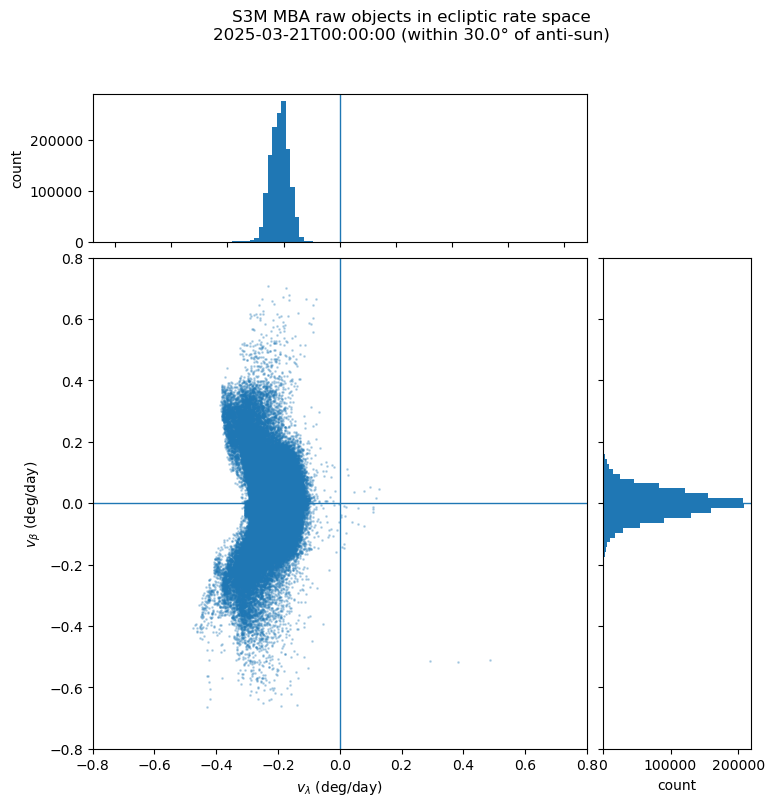

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

import astropy.units as u
from astropy.time import Time
from astropy.coordinates import SkyCoord, GCRS, get_sun

obstime_str = "2025-03-21T00:00:00"
t_obs = Time(obstime_str, scale="tdb")

max_sep_deg = 30.0         
Nsample = None              

xlim = (-0.8, 0.8)
ylim = (-0.8, 0.8)
bins = 100                  

AU_km  = 149_597_870.7
mu_sun = 1.32712440018e11   # km^3/s^2

#Pull columns

a_AU   = s3m["a"].to_numpy(dtype=float)
e      = s3m["e"].to_numpy(dtype=float)
inc    = s3m["i"].to_numpy(dtype=float)        # deg
raan   = s3m["node"].to_numpy(dtype=float)     # deg
argp   = s3m["argperi"].to_numpy(dtype=float)  # deg
tp_mjd = s3m["t_p"].to_numpy(dtype=float)      # MJD

N = len(a_AU)
if (Nsample is not None) and (N > Nsample):
    idx = np.random.choice(N, Nsample, replace=False)
    a_AU, e, inc, raan, argp, tp_mjd = a_AU[idx], e[idx], inc[idx], raan[idx], argp[idx], tp_mjd[idx]
    print("Sample size:", len(a_AU))
else:
    print("Using ALL rows:", len(a_AU))



r_obj_ecl, v_obj_ecl = nsc.elements_to_helio_ecliptic_state(
    a_AU=a_AU,
    e=e,
    inc_deg=inc,
    raan_deg=raan,
    argp_deg=argp,
    tp_mjd=tp_mjd,
    obstime_str=obstime_str,
    method="newton",      # change to "adam" to use ADAM
    n_iter=10,
    chunk=300_000,
    show_progress=True,
)


#Ecliptic -> Equatorial 

eps = np.deg2rad(23.439291)
c, s = np.cos(eps), np.sin(eps)

r_obj_helio = np.column_stack([
    r_obj_ecl[:, 0],
    c*r_obj_ecl[:, 1] - s*r_obj_ecl[:, 2],
    s*r_obj_ecl[:, 1] + c*r_obj_ecl[:, 2],
])

v_obj_helio = np.column_stack([
    v_obj_ecl[:, 0],
    c*v_obj_ecl[:, 1] - s*v_obj_ecl[:, 2],
    s*v_obj_ecl[:, 1] + c*v_obj_ecl[:, 2],
])


# Observer state from scorer (Earth + Rubin topocenter)

_, rE, vE, r_tele = scorer_mba_s3m._get_earth_and_observer(obstime_str)

# Topocentric relative vectors (aka r_rel, v_rel)
r_rel = r_obj_helio - (rE + r_tele)   # km
v_rel = v_obj_helio - vE              # km/s


#(r_rel, v_rel) -> RA/Dec and RA/Dec rates

x, y, z = r_rel[:, 0], r_rel[:, 1], r_rel[:, 2]
vx, vy, vz = v_rel[:, 0], v_rel[:, 1], v_rel[:, 2]

rho2 = x*x + y*y
r2   = rho2 + z*z
rho  = np.sqrt(rho2)

ra  = np.arctan2(y, x)
dec = np.arctan2(z, rho)

dra  = (x*vy - y*vx) / rho2
ddec = (vz*rho2 - z*(x*vx + y*vy)) / (r2 * rho)


good = (
    np.isfinite(ra) & np.isfinite(dec) &
    np.isfinite(dra) & np.isfinite(ddec) &
    (rho2 > 0) & np.isfinite(r2) & (r2 > 0)
)

ra_deg  = (np.rad2deg(ra[good]) % 360.0)
dec_deg = np.rad2deg(dec[good])

# dra/ddec above are rad/s -> convert to deg/day
dra_deg_day  = np.rad2deg(dra[good])  * 86400.0
ddec_deg_day = np.rad2deg(ddec[good]) * 86400.0


#Anti-sun cone cut

sun_gcrs = get_sun(t_obs).transform_to(GCRS(obstime=t_obs))
anti = SkyCoord(
    x=-sun_gcrs.cartesian.x,
    y=-sun_gcrs.cartesian.y,
    z=-sun_gcrs.cartesian.z,
    representation_type="cartesian",
    frame=GCRS(obstime=t_obs),
)

anti_ra_deg  = anti.spherical.lon.to_value(u.deg) % 360.0
anti_dec_deg = anti.spherical.lat.to_value(u.deg)

print("anti-sun RA,Dec:", anti_ra_deg, anti_dec_deg)

sc = SkyCoord(ra=ra_deg*u.deg, dec=dec_deg*u.deg, frame=GCRS(obstime=t_obs))
anti_sc = SkyCoord(ra=anti_ra_deg*u.deg, dec=anti_dec_deg*u.deg, frame=GCRS(obstime=t_obs))
sep = sc.separation(anti_sc).deg


m = sep <= max_sep_deg
ra_deg, dec_deg = ra_deg[m], dec_deg[m]
dra_deg_day, ddec_deg_day = dra_deg_day[m], ddec_deg_day[m]

print(f"After anti-sun sep < {max_sep_deg}°:", len(ra_deg))




# RA/Dec rates -> ecliptic rates

vlam, vbeta = nsc.radec_rates_to_ecliptic_rates_at_obstime(
    ra_deg, dec_deg,
    dra_deg_day, ddec_deg_day,
    obstime_str
)

finite = np.isfinite(vlam) & np.isfinite(vbeta)
vlam = vlam[finite]
vbeta = vbeta[finite]

# copying vlam/vbet values

vlam_mba  = vlam.copy()
vbeta_mba = vbeta.copy()

# Scatter + marginal histograms 

fig = plt.figure(figsize=(8.5, 8.5))
gs = fig.add_gridspec(
    nrows=2, ncols=2,
    width_ratios=[4.0, 1.2],
    height_ratios=[1.2, 4.0],
    wspace=0.05, hspace=0.05
)

ax_histx = fig.add_subplot(gs[0, 0])
ax_scatt = fig.add_subplot(gs[1, 0])
ax_histy = fig.add_subplot(gs[1, 1], sharey=ax_scatt)

# Scatter
ax_scatt.scatter(vlam, vbeta, s=1, alpha=0.25)
ax_scatt.axhline(0, lw=1)
ax_scatt.axvline(0, lw=1)
ax_scatt.set_xlabel(r"$v_\lambda$ (deg/day)")
ax_scatt.set_ylabel(r"$v_\beta$ (deg/day)")
ax_scatt.set_xlim(*xlim)
ax_scatt.set_ylim(*ylim)

# Top histogram (v_lambda)
ax_histx.hist(vlam, bins=bins, range=xlim)
ax_histx.axvline(0, lw=1)
ax_histx.tick_params(axis="x", labelbottom=False)
ax_histx.set_ylabel("count")

# Right histogram (v_beta)
ax_histy.hist(vbeta, bins=bins, range=ylim, orientation="horizontal")
ax_histy.axhline(0, lw=1)
ax_histy.tick_params(axis="y", labelleft=False)
ax_histy.set_xlabel("count")

fig.suptitle(f"S3M MBA raw objects in ecliptic rate space\n{obstime_str} (within {max_sep_deg}° of anti-sun)", y=0.98)
plt.show()



#### same plot but w NEOs

In [9]:
neo = load_s3m.define_s3m(pop="neo")
neo, array4D_neo, H_center_neo, a_center_neo, e_center_neo, i_center_neo = load_s3m.s3m_array(neo)
scorer_neo_s3m = nsc.NEOMODScorer(array4D_neo, H_center_neo, a_center_neo, e_center_neo, i_center_neo)

Search pattern: S0.s3m
Search dirs: ['.', 'S3Mdata']
Matched files: ['./S0.s3m']
Loaded 1 file(s).
Final dataframe shape: (268511, 15)
The final df is done.


Using ALL rows: 268511


Propagate with newton: 100%|██████████| 1/1 [00:00<00:00,  4.44it/s]


After good-mask: 268511
After anti-sun sep < 30.0°: 13485
Finite vlam/vbeta: 13485


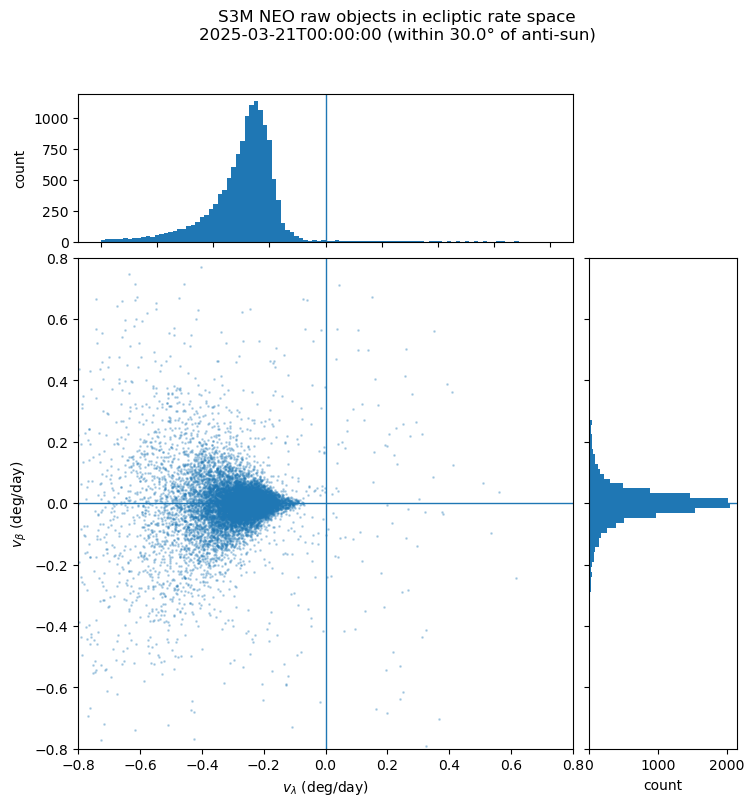

In [10]:
obstime_str = "2025-03-21T00:00:00"
t_obs = Time(obstime_str, scale="tdb")

max_sep_deg = 30.0         
Nsample = None              

xlim = (-0.8, 0.8)
ylim = (-0.8, 0.8)
bins = 100                  

AU_km  = 149_597_870.7
mu_sun = 1.32712440018e11   # km^3/s^2

#Pull columns

a_AU   = neo["a"].to_numpy(dtype=float)
e      = neo["e"].to_numpy(dtype=float)
inc    = neo["i"].to_numpy(dtype=float)        # deg
raan   = neo["node"].to_numpy(dtype=float)     # deg
argp   = neo["argperi"].to_numpy(dtype=float)  # deg
tp_mjd = neo["t_p"].to_numpy(dtype=float)      # MJD

N = len(a_AU)
if (Nsample is not None) and (N > Nsample):
    idx = np.random.choice(N, Nsample, replace=False)
    a_AU, e, inc, raan, argp, tp_mjd = a_AU[idx], e[idx], inc[idx], raan[idx], argp[idx], tp_mjd[idx]
    print("Sample size:", len(a_AU))
else:
    print("Using ALL rows:", len(a_AU))


r_obj_ecl, v_obj_ecl = nsc.elements_to_helio_ecliptic_state(
    a_AU=a_AU,
    e=e,
    inc_deg=inc,
    raan_deg=raan,
    argp_deg=argp,
    tp_mjd=tp_mjd,
    obstime_str=obstime_str,
    method="newton",      # change to "adam" to use ADAM
    n_iter=10,
    chunk=300_000,
    show_progress=True,
)


#Ecliptic -> Equatorial 

eps = np.deg2rad(23.439291)
c, s = np.cos(eps), np.sin(eps)

r_obj_helio = np.column_stack([
    r_obj_ecl[:, 0],
    c*r_obj_ecl[:, 1] - s*r_obj_ecl[:, 2],
    s*r_obj_ecl[:, 1] + c*r_obj_ecl[:, 2],
])

v_obj_helio = np.column_stack([
    v_obj_ecl[:, 0],
    c*v_obj_ecl[:, 1] - s*v_obj_ecl[:, 2],
    s*v_obj_ecl[:, 1] + c*v_obj_ecl[:, 2],
])


# Observer state from scorer (Earth + Rubin topocenter)

_, rE, vE, r_tele = scorer_neo_s3m._get_earth_and_observer(obstime_str)

# Topocentric relative vectors (aka r_rel, v_rel)
r_rel = r_obj_helio - (rE + r_tele)   # km
v_rel = v_obj_helio - vE              # km/s


#(r_rel, v_rel) -> RA/Dec and RA/Dec rates

x, y, z = r_rel[:, 0], r_rel[:, 1], r_rel[:, 2]
vx, vy, vz = v_rel[:, 0], v_rel[:, 1], v_rel[:, 2]

rho2 = x*x + y*y
r2   = rho2 + z*z
rho  = np.sqrt(rho2)

ra  = np.arctan2(y, x)
dec = np.arctan2(z, rho)

dra  = (x*vy - y*vx) / rho2
ddec = (vz*rho2 - z*(x*vx + y*vy)) / (r2 * rho)

good = (
    np.isfinite(ra) & np.isfinite(dec) &
    np.isfinite(dra) & np.isfinite(ddec) &
    (rho2 > 0) & np.isfinite(r2) & (r2 > 0)
)

ra_deg  = (np.rad2deg(ra[good]) % 360.0)
dec_deg = np.rad2deg(dec[good])

# dra/ddec above are rad/s -> convert to deg/day
dra_deg_day  = np.rad2deg(dra[good])  * 86400.0
ddec_deg_day = np.rad2deg(ddec[good]) * 86400.0

print("After good-mask:", len(ra_deg))


#Anti-sun cone cut

sun_gcrs = get_sun(t_obs).transform_to(GCRS(obstime=t_obs))
anti = SkyCoord(
    x=-sun_gcrs.cartesian.x,
    y=-sun_gcrs.cartesian.y,
    z=-sun_gcrs.cartesian.z,
    representation_type="cartesian",
    frame=GCRS(obstime=t_obs),
)

anti_ra_deg  = anti.spherical.lon.to_value(u.deg) % 360.0
anti_dec_deg = anti.spherical.lat.to_value(u.deg)

sc = SkyCoord(ra=ra_deg*u.deg, dec=dec_deg*u.deg, frame=GCRS(obstime=t_obs))
anti_sc = SkyCoord(ra=anti_ra_deg*u.deg, dec=anti_dec_deg*u.deg, frame=GCRS(obstime=t_obs))
sep = sc.separation(anti_sc).deg

m = sep <= max_sep_deg
ra_deg, dec_deg = ra_deg[m], dec_deg[m]
dra_deg_day, ddec_deg_day = dra_deg_day[m], ddec_deg_day[m]

print(f"After anti-sun sep < {max_sep_deg}°:", len(ra_deg))


# RA/Dec rates -> ecliptic rates

vlam, vbeta = nsc.radec_rates_to_ecliptic_rates_at_obstime(
    ra_deg, dec_deg,
    dra_deg_day, ddec_deg_day,
    obstime_str
)

finite = np.isfinite(vlam) & np.isfinite(vbeta)
vlam = vlam[finite]
vbeta = vbeta[finite]
print("Finite vlam/vbeta:", len(vlam))

# copying vlam/vbet values
vlam_neo  = vlam.copy()
vbeta_neo = vbeta.copy()


# Scatter + marginal histograms 

fig = plt.figure(figsize=(8.5, 8.5))
gs = fig.add_gridspec(
    nrows=2, ncols=2,
    width_ratios=[4.0, 1.2],
    height_ratios=[1.2, 4.0],
    wspace=0.05, hspace=0.05
)

ax_histx = fig.add_subplot(gs[0, 0])
ax_scatt = fig.add_subplot(gs[1, 0])
ax_histy = fig.add_subplot(gs[1, 1], sharey=ax_scatt)

# Scatter
ax_scatt.scatter(vlam, vbeta, s=1, alpha=0.25)
ax_scatt.axhline(0, lw=1)
ax_scatt.axvline(0, lw=1)
ax_scatt.set_xlabel(r"$v_\lambda$ (deg/day)")
ax_scatt.set_ylabel(r"$v_\beta$ (deg/day)")
ax_scatt.set_xlim(*xlim)
ax_scatt.set_ylim(*ylim)

# Top histogram (v_lambda)
ax_histx.hist(vlam, bins=bins, range=xlim)
ax_histx.axvline(0, lw=1)
ax_histx.tick_params(axis="x", labelbottom=False)
ax_histx.set_ylabel("count")

# Right histogram (v_beta)
ax_histy.hist(vbeta, bins=bins, range=ylim, orientation="horizontal")
ax_histy.axhline(0, lw=1)
ax_histy.tick_params(axis="y", labelleft=False)
ax_histy.set_xlabel("count")

fig.suptitle(f"S3M NEO raw objects in ecliptic rate space\n{obstime_str} (within {max_sep_deg}° of anti-sun)", y=0.98)
plt.show()



### TNOS!!!

In [11]:
tno = load_s3m.define_s3m(pop="tno")
tno, array4D_tno, H_center_tno, a_center_tno, e_center_tno, i_center_tno = load_s3m.s3m_array(tno)
scorer_tno_s3m = nsc.NEOMODScorer(array4D_tno, H_center_tno, a_center_tno, e_center_tno, i_center_tno)

Search pattern: ST.s3m
Search dirs: ['.', 'S3Mdata']
Matched files: ['./ST.s3m']
Loaded 1 file(s).
Final dataframe shape: (48682, 15)
The final df is done.


Using ALL rows: 48682


Propagate with newton: 100%|██████████| 1/1 [00:00<00:00, 27.05it/s]

After good-mask: 48682
After anti-sun sep < 30.0°: 7417
Finite vlam/vbeta: 7417


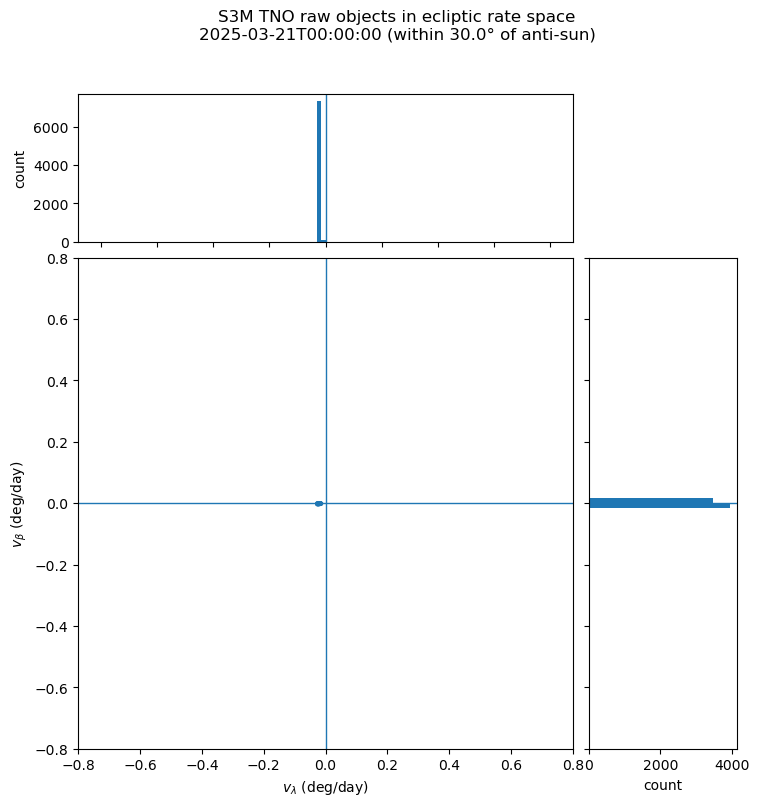

In [12]:
obstime_str = "2025-03-21T00:00:00"
t_obs = Time(obstime_str, scale="tdb")

max_sep_deg = 30.0         
Nsample = None              

xlim = (-0.8, 0.8)
ylim = (-0.8, 0.8)
bins = 100                  

AU_km  = 149_597_870.7
mu_sun = 1.32712440018e11   # km^3/s^2

#Pull columns

a_AU   = tno["a"].to_numpy(dtype=float)
e      = tno["e"].to_numpy(dtype=float)
inc    = tno["i"].to_numpy(dtype=float)        # deg
raan   = tno["node"].to_numpy(dtype=float)     # deg
argp   = tno["argperi"].to_numpy(dtype=float)  # deg
tp_mjd = tno["t_p"].to_numpy(dtype=float)      # MJD

N = len(a_AU)
if (Nsample is not None) and (N > Nsample):
    idx = np.random.choice(N, Nsample, replace=False)
    a_AU, e, inc, raan, argp, tp_mjd = a_AU[idx], e[idx], inc[idx], raan[idx], argp[idx], tp_mjd[idx]
    print("Sample size:", len(a_AU))
else:
    print("Using ALL rows:", len(a_AU))


r_obj_ecl, v_obj_ecl = nsc.elements_to_helio_ecliptic_state(
    a_AU=a_AU,
    e=e,
    inc_deg=inc,
    raan_deg=raan,
    argp_deg=argp,
    tp_mjd=tp_mjd,
    obstime_str=obstime_str,
    method="newton",      # change to "adam" to use ADAM
    n_iter=10,
    chunk=300_000,
    show_progress=True,
)

#Ecliptic -> Equatorial 

eps = np.deg2rad(23.439291)
c, s = np.cos(eps), np.sin(eps)

r_obj_helio = np.column_stack([
    r_obj_ecl[:, 0],
    c*r_obj_ecl[:, 1] - s*r_obj_ecl[:, 2],
    s*r_obj_ecl[:, 1] + c*r_obj_ecl[:, 2],
])

v_obj_helio = np.column_stack([
    v_obj_ecl[:, 0],
    c*v_obj_ecl[:, 1] - s*v_obj_ecl[:, 2],
    s*v_obj_ecl[:, 1] + c*v_obj_ecl[:, 2],
])


# Observer state from scorer (Earth + Rubin topocenter)

_, rE, vE, r_tele = scorer_tno_s3m._get_earth_and_observer(obstime_str)

# Topocentric relative vectors (aka r_rel, v_rel)
r_rel = r_obj_helio - (rE + r_tele)   # km
v_rel = v_obj_helio - vE              # km/s


#(r_rel, v_rel) -> RA/Dec and RA/Dec rates

x, y, z = r_rel[:, 0], r_rel[:, 1], r_rel[:, 2]
vx, vy, vz = v_rel[:, 0], v_rel[:, 1], v_rel[:, 2]

rho2 = x*x + y*y
r2   = rho2 + z*z
rho  = np.sqrt(rho2)

ra  = np.arctan2(y, x)
dec = np.arctan2(z, rho)

dra  = (x*vy - y*vx) / rho2
ddec = (vz*rho2 - z*(x*vx + y*vy)) / (r2 * rho)

good = (
    np.isfinite(ra) & np.isfinite(dec) &
    np.isfinite(dra) & np.isfinite(ddec) &
    (rho2 > 0) & np.isfinite(r2) & (r2 > 0)
)

ra_deg  = (np.rad2deg(ra[good]) % 360.0)
dec_deg = np.rad2deg(dec[good])

# dra/ddec above are rad/s -> convert to deg/day
dra_deg_day  = np.rad2deg(dra[good])  * 86400.0
ddec_deg_day = np.rad2deg(ddec[good]) * 86400.0

print("After good-mask:", len(ra_deg))


#Anti-sun cone cut

sun_gcrs = get_sun(t_obs).transform_to(GCRS(obstime=t_obs))
anti = SkyCoord(
    x=-sun_gcrs.cartesian.x,
    y=-sun_gcrs.cartesian.y,
    z=-sun_gcrs.cartesian.z,
    representation_type="cartesian",
    frame=GCRS(obstime=t_obs),
)

anti_ra_deg  = anti.spherical.lon.to_value(u.deg) % 360.0
anti_dec_deg = anti.spherical.lat.to_value(u.deg)

sc = SkyCoord(ra=ra_deg*u.deg, dec=dec_deg*u.deg, frame=GCRS(obstime=t_obs))
anti_sc = SkyCoord(ra=anti_ra_deg*u.deg, dec=anti_dec_deg*u.deg, frame=GCRS(obstime=t_obs))
sep = sc.separation(anti_sc).deg

m = sep <= max_sep_deg
ra_deg, dec_deg = ra_deg[m], dec_deg[m]
dra_deg_day, ddec_deg_day = dra_deg_day[m], ddec_deg_day[m]

print(f"After anti-sun sep < {max_sep_deg}°:", len(ra_deg))


# RA/Dec rates -> ecliptic rates

vlam, vbeta = nsc.radec_rates_to_ecliptic_rates_at_obstime(
    ra_deg, dec_deg,
    dra_deg_day, ddec_deg_day,
    obstime_str
)

finite = np.isfinite(vlam) & np.isfinite(vbeta)
vlam = vlam[finite]
vbeta = vbeta[finite]
print("Finite vlam/vbeta:", len(vlam))

# copying vlam/vbet values
vlam_tno  = vlam.copy()
vbeta_tno = vbeta.copy()


# Scatter + marginal histograms 

fig = plt.figure(figsize=(8.5, 8.5))
gs = fig.add_gridspec(
    nrows=2, ncols=2,
    width_ratios=[4.0, 1.2],
    height_ratios=[1.2, 4.0],
    wspace=0.05, hspace=0.05
)

ax_histx = fig.add_subplot(gs[0, 0])
ax_scatt = fig.add_subplot(gs[1, 0])
ax_histy = fig.add_subplot(gs[1, 1], sharey=ax_scatt)

# Scatter
ax_scatt.scatter(vlam, vbeta, s=1, alpha=0.25)
ax_scatt.axhline(0, lw=1)
ax_scatt.axvline(0, lw=1)
ax_scatt.set_xlabel(r"$v_\lambda$ (deg/day)")
ax_scatt.set_ylabel(r"$v_\beta$ (deg/day)")
ax_scatt.set_xlim(*xlim)
ax_scatt.set_ylim(*ylim)

# Top histogram (v_lambda)
ax_histx.hist(vlam, bins=bins, range=xlim)
ax_histx.axvline(0, lw=1)
ax_histx.tick_params(axis="x", labelbottom=False)
ax_histx.set_ylabel("count")

# Right histogram (v_beta)
ax_histy.hist(vbeta, bins=bins, range=ylim, orientation="horizontal")
ax_histy.axhline(0, lw=1)
ax_histy.tick_params(axis="y", labelleft=False)
ax_histy.set_xlabel("count")

fig.suptitle(f"S3M TNO raw objects in ecliptic rate space\n{obstime_str} (within {max_sep_deg}° of anti-sun)", y=0.98)
plt.show()


### trojan empire

In [13]:
trojan = load_s3m.define_s3m(pop="trojan")
trojan,array4D_tjn, H_center_tjn, a_center_tjn, e_center_tjn, i_center_tjn = load_s3m.s3m_array(trojan)
scorer_tjn_s3m = nsc.NEOMODScorer(array4D_tjn, H_center_tjn, a_center_tjn, e_center_tjn, i_center_tjn)

Search pattern: St5.s3m
Search dirs: ['.', 'S3Mdata']
Matched files: ['./St5.s3m']
Loaded 1 file(s).
Final dataframe shape: (179882, 15)
The final df is done.


Using ALL rows: 179882


Propagate with newton: 100%|██████████| 1/1 [00:00<00:00,  7.81it/s]

After good-mask: 179882
After anti-sun sep < 30.0°: 23188


Finite vlam/vbeta: 23188


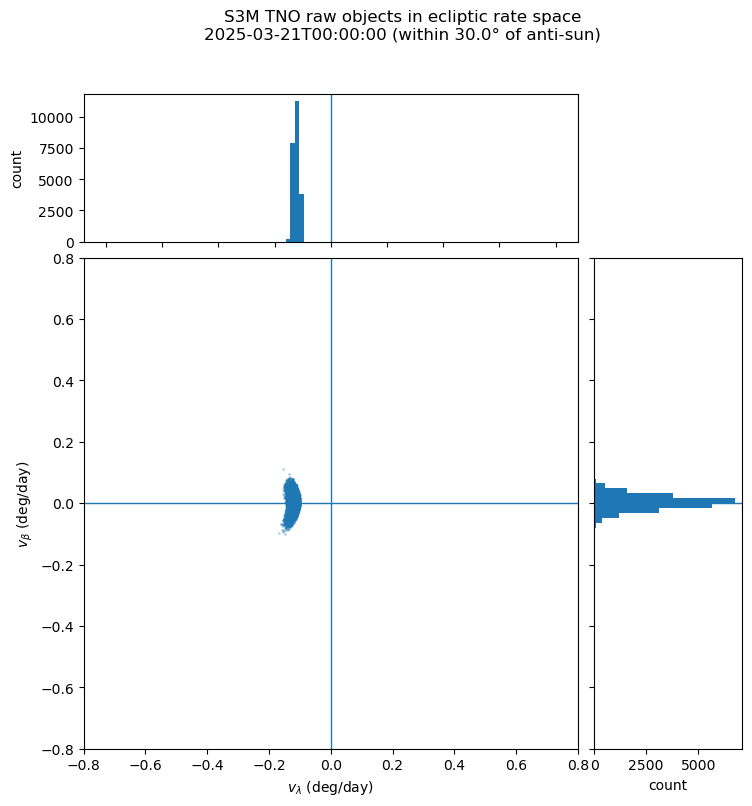

In [14]:
obstime_str = "2025-03-21T00:00:00"
t_obs = Time(obstime_str, scale="tdb")

max_sep_deg = 30.0         
Nsample = None              

xlim = (-0.8, 0.8)
ylim = (-0.8, 0.8)
bins = 100                  

AU_km  = 149_597_870.7
mu_sun = 1.32712440018e11   # km^3/s^2

#Pull columns

a_AU   = trojan["a"].to_numpy(dtype=float)
e      = trojan["e"].to_numpy(dtype=float)
inc    = trojan["i"].to_numpy(dtype=float)        # deg
raan   = trojan["node"].to_numpy(dtype=float)     # deg
argp   = trojan["argperi"].to_numpy(dtype=float)  # deg
tp_mjd = trojan["t_p"].to_numpy(dtype=float)      # MJD

N = len(a_AU)
if (Nsample is not None) and (N > Nsample):
    idx = np.random.choice(N, Nsample, replace=False)
    a_AU, e, inc, raan, argp, tp_mjd = a_AU[idx], e[idx], inc[idx], raan[idx], argp[idx], tp_mjd[idx]
    print("Sample size:", len(a_AU))
else:
    print("Using ALL rows:", len(a_AU))


r_obj_ecl, v_obj_ecl = nsc.elements_to_helio_ecliptic_state(
    a_AU=a_AU,
    e=e,
    inc_deg=inc,
    raan_deg=raan,
    argp_deg=argp,
    tp_mjd=tp_mjd,
    obstime_str=obstime_str,
    method="newton",      # change to "adam" to use ADAM
    n_iter=10,
    chunk=300_000,
    show_progress=True,
)


#Ecliptic -> Equatorial 

eps = np.deg2rad(23.439291)
c, s = np.cos(eps), np.sin(eps)

r_obj_helio = np.column_stack([
    r_obj_ecl[:, 0],
    c*r_obj_ecl[:, 1] - s*r_obj_ecl[:, 2],
    s*r_obj_ecl[:, 1] + c*r_obj_ecl[:, 2],
])

v_obj_helio = np.column_stack([
    v_obj_ecl[:, 0],
    c*v_obj_ecl[:, 1] - s*v_obj_ecl[:, 2],
    s*v_obj_ecl[:, 1] + c*v_obj_ecl[:, 2],
])


# Observer state from scorer (Earth + Rubin topocenter)

_, rE, vE, r_tele = scorer_tjn_s3m._get_earth_and_observer(obstime_str)

# Topocentric relative vectors (aka r_rel, v_rel)
r_rel = r_obj_helio - (rE + r_tele)   # km
v_rel = v_obj_helio - vE              # km/s


#(r_rel, v_rel) -> RA/Dec and RA/Dec rates

x, y, z = r_rel[:, 0], r_rel[:, 1], r_rel[:, 2]
vx, vy, vz = v_rel[:, 0], v_rel[:, 1], v_rel[:, 2]

rho2 = x*x + y*y
r2   = rho2 + z*z
rho  = np.sqrt(rho2)

ra  = np.arctan2(y, x)
dec = np.arctan2(z, rho)

dra  = (x*vy - y*vx) / rho2
ddec = (vz*rho2 - z*(x*vx + y*vy)) / (r2 * rho)

good = (
    np.isfinite(ra) & np.isfinite(dec) &
    np.isfinite(dra) & np.isfinite(ddec) &
    (rho2 > 0) & np.isfinite(r2) & (r2 > 0)
)

ra_deg  = (np.rad2deg(ra[good]) % 360.0)
dec_deg = np.rad2deg(dec[good])

# dra/ddec above are rad/s -> convert to deg/day
dra_deg_day  = np.rad2deg(dra[good])  * 86400.0
ddec_deg_day = np.rad2deg(ddec[good]) * 86400.0

print("After good-mask:", len(ra_deg))


#Anti-sun cone cut

sun_gcrs = get_sun(t_obs).transform_to(GCRS(obstime=t_obs))
anti = SkyCoord(
    x=-sun_gcrs.cartesian.x,
    y=-sun_gcrs.cartesian.y,
    z=-sun_gcrs.cartesian.z,
    representation_type="cartesian",
    frame=GCRS(obstime=t_obs),
)

anti_ra_deg  = anti.spherical.lon.to_value(u.deg) % 360.0
anti_dec_deg = anti.spherical.lat.to_value(u.deg)

sc = SkyCoord(ra=ra_deg*u.deg, dec=dec_deg*u.deg, frame=GCRS(obstime=t_obs))
anti_sc = SkyCoord(ra=anti_ra_deg*u.deg, dec=anti_dec_deg*u.deg, frame=GCRS(obstime=t_obs))
sep = sc.separation(anti_sc).deg

m = sep <= max_sep_deg
ra_deg, dec_deg = ra_deg[m], dec_deg[m]
dra_deg_day, ddec_deg_day = dra_deg_day[m], ddec_deg_day[m]

print(f"After anti-sun sep < {max_sep_deg}°:", len(ra_deg))


# RA/Dec rates -> ecliptic rates

vlam, vbeta = nsc.radec_rates_to_ecliptic_rates_at_obstime(
    ra_deg, dec_deg,
    dra_deg_day, ddec_deg_day,
    obstime_str
)

finite = np.isfinite(vlam) & np.isfinite(vbeta)
vlam = vlam[finite]
vbeta = vbeta[finite]
print("Finite vlam/vbeta:", len(vlam))

# copying vlam/vbet values
vlam_tjn  = vlam.copy()
vbeta_tjn = vbeta.copy()


# Scatter + marginal histograms 

fig = plt.figure(figsize=(8.5, 8.5))
gs = fig.add_gridspec(
    nrows=2, ncols=2,
    width_ratios=[4.0, 1.2],
    height_ratios=[1.2, 4.0],
    wspace=0.05, hspace=0.05
)

ax_histx = fig.add_subplot(gs[0, 0])
ax_scatt = fig.add_subplot(gs[1, 0])
ax_histy = fig.add_subplot(gs[1, 1], sharey=ax_scatt)

# Scatter
ax_scatt.scatter(vlam, vbeta, s=1, alpha=0.25)
ax_scatt.axhline(0, lw=1)
ax_scatt.axvline(0, lw=1)
ax_scatt.set_xlabel(r"$v_\lambda$ (deg/day)")
ax_scatt.set_ylabel(r"$v_\beta$ (deg/day)")
ax_scatt.set_xlim(*xlim)
ax_scatt.set_ylim(*ylim)

# Top histogram (v_lambda)
ax_histx.hist(vlam, bins=bins, range=xlim)
ax_histx.axvline(0, lw=1)
ax_histx.tick_params(axis="x", labelbottom=False)
ax_histx.set_ylabel("count")

# Right histogram (v_beta)
ax_histy.hist(vbeta, bins=bins, range=ylim, orientation="horizontal")
ax_histy.axhline(0, lw=1)
ax_histy.tick_params(axis="y", labelleft=False)
ax_histy.set_xlabel("count")

fig.suptitle(f"S3M TNO raw objects in ecliptic rate space\n{obstime_str} (within {max_sep_deg}° of anti-sun)", y=0.98)
plt.show()



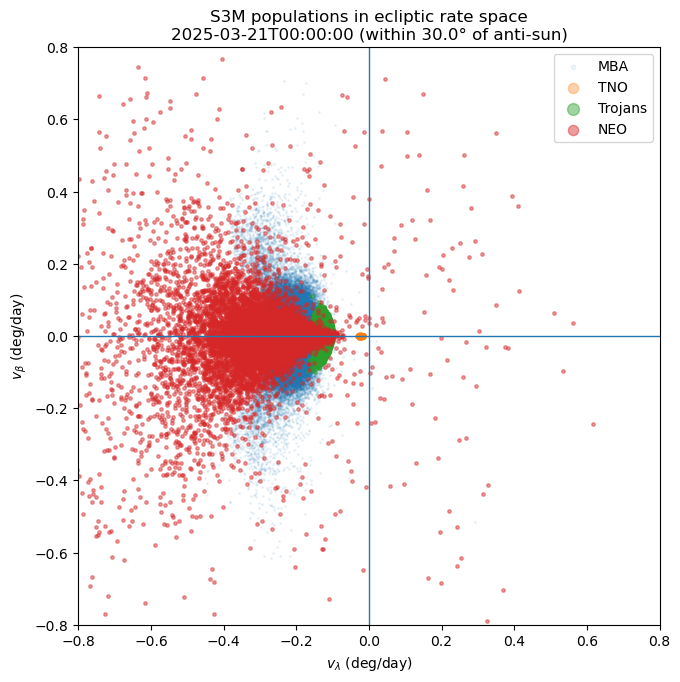

In [15]:
# Plotting limits (matching earlier cells)
xlim = (-0.8, 0.8)
ylim = (-0.8, 0.8)

# Down sampling for huge populations 
def downsample(x, y, nmax=250_000, seed=0):
    n = len(x)
    if n <= nmax:
        return x, y
    rng = np.random.default_rng(seed)
    idx = rng.choice(n, size=nmax, replace=False)
    return x[idx], y[idx]

# Down sampling MBA for visibility/speed
vlam_mba_ds, vbeta_mba_ds = downsample(vlam_mba, vbeta_mba, nmax=250_000, seed=1)

fig, ax = plt.subplots(figsize=(7.5, 7.5))

# Plotting order: big populations first, smaller on top
ax.scatter(vlam_mba_ds, vbeta_mba_ds, s=1, alpha=0.08, label="MBA", rasterized=True)
ax.scatter(vlam_tno,    vbeta_tno,    s=6, alpha=0.35, label="TNO", rasterized=True)
ax.scatter(vlam_tjn,    vbeta_tjn,    s=8, alpha=0.45, label="Trojans", rasterized=True)
ax.scatter(vlam_neo,    vbeta_neo,    s=6, alpha=0.45, label="NEO", rasterized=True)

ax.axhline(0, lw=1)
ax.axvline(0, lw=1)
ax.set_xlim(*xlim)
ax.set_ylim(*ylim)
ax.set_xlabel(r"$v_\lambda$ (deg/day)")
ax.set_ylabel(r"$v_\beta$ (deg/day)")

ax.legend(loc="upper right", frameon=True, markerscale=3)
ax.set_title(f"S3M populations in ecliptic rate space\n{obstime_str} (within {max_sep_deg}° of anti-sun)")

plt.show()


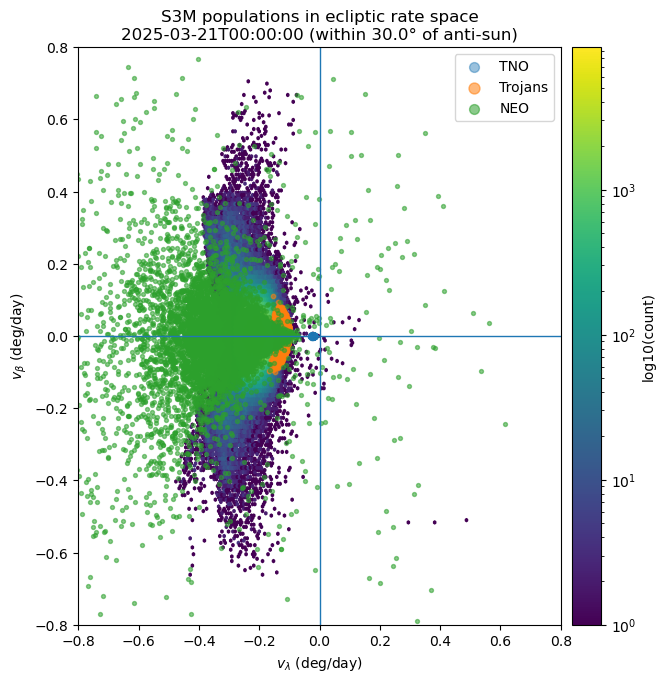

In [16]:
xlim = (-0.8, 0.8)
ylim = (-0.8, 0.8)

fig, ax = plt.subplots(figsize=(7.5, 7.5))

# MBA's as a density
hb = ax.hexbin(
    vlam_mba, vbeta_mba,
    gridsize=220,            # bigger = finer pixels (ranges: 160–320)
    extent=(*xlim, *ylim),
    mincnt=1,
    bins="log"               # log density so wings show up
)
cb = fig.colorbar(hb, ax=ax, pad=0.02)
cb.set_label("log10(count)")



\
ax.scatter(vlam_tno, vbeta_tno, s=8,  alpha=0.45, label="TNO",     rasterized=True)
ax.scatter(vlam_tjn, vbeta_tjn, s=10, alpha=0.55, label="Trojans", rasterized=True)
ax.scatter(vlam_neo, vbeta_neo, s=8,  alpha=0.55, label="NEO",     rasterized=True)


ax.axhline(0, lw=1)
ax.axvline(0, lw=1)
ax.set_xlim(*xlim)
ax.set_ylim(*ylim)
ax.set_xlabel(r"$v_\lambda$ (deg/day)")
ax.set_ylabel(r"$v_\beta$ (deg/day)")


ax.legend(loc="upper right", frameon=True, markerscale=2.5)

try:
    ax.set_title(f"S3M populations in ecliptic rate space\n{obstime_str} (within {max_sep_deg}° of anti-sun)")
except NameError:
    ax.set_title("S3M populations in ecliptic rate space")

plt.show()


In [17]:

obstime_str = "2025-03-21T00:00:00"
t_obs = Time(obstime_str, scale="tdb")

max_sep_deg = 30.0
Nsample = None

AU_km = 149_597_870.7
mu_sun = 1.32712440018e11  # km^3/s^2


a_AU   = s3m["a"].to_numpy(dtype=float)
e      = s3m["e"].to_numpy(dtype=float)
inc    = s3m["i"].to_numpy(dtype=float)
raan   = s3m["node"].to_numpy(dtype=float)
argp   = s3m["argperi"].to_numpy(dtype=float)
tp_mjd = s3m["t_p"].to_numpy(dtype=float)


row_idx = np.arange(len(s3m))


N = len(a_AU)
if (Nsample is not None) and (N > Nsample):
    take = np.random.choice(N, Nsample, replace=False)
    a_AU, e, inc, raan, argp, tp_mjd = (
        a_AU[take], e[take], inc[take], raan[take], argp[take], tp_mjd[take]
    )
    row_idx = row_idx[take]

print("Starting rows:", len(row_idx))

r_obj_ecl, v_obj_ecl = nsc.elements_to_helio_ecliptic_state(
    a_AU=a_AU,
    e=e,
    inc_deg=inc,
    raan_deg=raan,
    argp_deg=argp,
    tp_mjd=tp_mjd,
    obstime_str=obstime_str,
    method="newton",
    n_iter=10,
    chunk=300_000,
    show_progress=True,
)


eps = np.deg2rad(23.439291)
c, s = np.cos(eps), np.sin(eps)

r_obj_helio = np.column_stack([
    r_obj_ecl[:, 0],
    c * r_obj_ecl[:, 1] - s * r_obj_ecl[:, 2],
    s * r_obj_ecl[:, 1] + c * r_obj_ecl[:, 2],
])

v_obj_helio = np.column_stack([
    v_obj_ecl[:, 0],
    c * v_obj_ecl[:, 1] - s * v_obj_ecl[:, 2],
    s * v_obj_ecl[:, 1] + c * v_obj_ecl[:, 2],
])

# --- observer state ---
_, rE, vE, r_tele = scorer_mba_s3m._get_earth_and_observer(obstime_str)

# --- topocentric relative vectors ---
r_rel = r_obj_helio - (rE + r_tele)
v_rel = v_obj_helio - vE

# --- (r_rel, v_rel) -> RA/Dec and rates ---
x, y, z = r_rel[:, 0], r_rel[:, 1], r_rel[:, 2]
vx, vy, vz = v_rel[:, 0], v_rel[:, 1], v_rel[:, 2]

rho2 = x*x + y*y
r2   = rho2 + z*z
rho  = np.sqrt(rho2)

ra  = np.arctan2(y, x)
dec = np.arctan2(z, rho)

dra  = (x*vy - y*vx) / rho2
ddec = (vz*rho2 - z*(x*vx + y*vy)) / (r2 * rho)

good_mask = (
    np.isfinite(ra) & np.isfinite(dec) &
    np.isfinite(dra) & np.isfinite(ddec) &
    (rho2 > 0) & np.isfinite(r2) & (r2 > 0)
)


row_idx_good = row_idx[good_mask]

ra_deg  = (np.rad2deg(ra[good_mask]) % 360.0)
dec_deg = np.rad2deg(dec[good_mask])

dra_deg_day  = np.rad2deg(dra[good_mask])  * 86400.0
ddec_deg_day = np.rad2deg(ddec[good_mask]) * 86400.0

print("After good_mask:", len(row_idx_good))


sun_gcrs = get_sun(t_obs).transform_to(GCRS(obstime=t_obs))
anti = SkyCoord(
    x=-sun_gcrs.cartesian.x,
    y=-sun_gcrs.cartesian.y,
    z=-sun_gcrs.cartesian.z,
    representation_type="cartesian",
    frame=GCRS(obstime=t_obs),
)

anti_ra_deg  = anti.spherical.lon.to_value(u.deg) % 360.0
anti_dec_deg = anti.spherical.lat.to_value(u.deg)

sc = SkyCoord(ra=ra_deg*u.deg, dec=dec_deg*u.deg, frame=GCRS(obstime=t_obs))
anti_sc = SkyCoord(ra=anti_ra_deg*u.deg, dec=anti_dec_deg*u.deg, frame=GCRS(obstime=t_obs))
sep = sc.separation(anti_sc).deg

anti_mask = sep <= max_sep_deg
row_idx_anti = row_idx_good[anti_mask]

ra_deg, dec_deg = ra_deg[anti_mask], dec_deg[anti_mask]
dra_deg_day, ddec_deg_day = dra_deg_day[anti_mask], ddec_deg_day[anti_mask]

print("After anti-sun cut:", len(row_idx_anti))

# --- RA/Dec rates -> ecliptic rates ---
vlam, vbeta = nsc.radec_rates_to_ecliptic_rates_at_obstime(
    ra_deg, dec_deg,
    dra_deg_day, ddec_deg_day,
    obstime_str
)

finite_mask = np.isfinite(vlam) & np.isfinite(vbeta)
row_idx_final = row_idx_anti[finite_mask]

vlam_mba = vlam[finite_mask].copy()
vbeta_mba = vbeta[finite_mask].copy()

print("Final aligned MBA points:", len(row_idx_final))
print("len(vlam_mba):", len(vlam_mba))
print("len(vbeta_mba):", len(vbeta_mba))

Starting rows: 13883361


Propagate with newton: 100%|██████████| 47/47 [00:10<00:00,  4.41it/s]


After good_mask: 13883361
After anti-sun cut: 1409982
Final aligned MBA points: 1409982
len(vlam_mba): 1409982
len(vbeta_mba): 1409982


len(s3m_mba_aligned): 1409982
len(vlam_mba): 1409982


,OID,a,e,i,node,argperi,t_p,vlam,vbeta,dist
825312,S101gPlsa,2.970285,0.56688,7.99574,0.04022,192.18616,51415.56634,0.384028,-0.518199,0.024213
1409807,S10biylTa,2.971156,0.56594,8.23782,356.41686,200.87480,51413.98291,0.487984,-0.510753,0.088639
780064,S101aAuHa,2.971015,0.56702,7.77779,353.60773,197.25513,51414.24814,0.291136,-0.515786,0.110002
847536,S101jThEa,2.415184,0.40212,20.60367,340.09333,141.56257,52452.23847,-0.053995,-0.393176,0.466393
1409197,S109qqX9a,2.379060,0.37002,21.47834,348.22301,133.21312,52632.57772,-0.089001,-0.450500,0.491500
1408809,S108D5H2a,2.307354,0.33448,22.33120,356.52490,131.96956,54284.68791,-0.104165,-0.536877,0.505512
1400234,S105P6b8a,2.376878,0.36502,21.43885,341.28973,136.35897,52635.56173,-0.094953,-0.366806,0.512562
668261,S100WIzMa,2.381218,0.36438,21.70953,352.64632,134.69882,52629.64891,-0.114733,-0.500790,0.514733
1027368,S101OFxva,2.371619,0.37148,21.47018,346.96843,118.70864,52642.74522,-0.101941,-0.372160,0.517965
907094,S101t233a,2.285314,0.33645,9.12152,25.19527,164.27326,54447.39497,-0.036150,-0.216542,0.520168


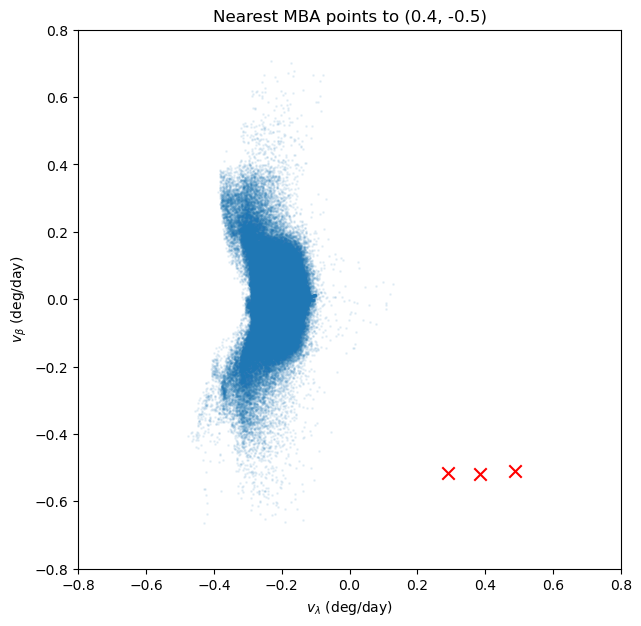

,OID,a,e,i,node,argperi,t_p
825312,S101gPlsa,2.970285,0.56688,7.99574,0.04022,192.18616,51415.56634
1409807,S10biylTa,2.971156,0.56594,8.23782,356.41686,200.87480,51413.98291
780064,S101aAuHa,2.971015,0.56702,7.77779,353.60773,197.25513,51414.24814


In [18]:
# Exact s3m rows corresponding to vlam_mba / vbeta_mba
s3m_mba_aligned = s3m.iloc[row_idx_final].reset_index(drop=True)

print("len(s3m_mba_aligned):", len(s3m_mba_aligned))
print("len(vlam_mba):", len(vlam_mba))

x0, y0 = 0.40, -0.50

dist = np.sqrt((vlam_mba - x0)**2 + (vbeta_mba - y0)**2)
idx = np.argsort(dist)[:10]

cols = ["OID", "a", "e", "i", "node", "argperi", "t_p"]
near = s3m_mba_aligned.iloc[idx][cols].copy()
near["vlam"] = vlam_mba[idx]
near["vbeta"] = vbeta_mba[idx]
near["dist"] = dist[idx]

display(near.sort_values("dist"))

idx3 = np.argsort(dist)[:3]

fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(vlam_mba, vbeta_mba, s=1, alpha=0.08)
ax.scatter(vlam_mba[idx3], vbeta_mba[idx3], s=80, color="red", marker="x")

ax.set_xlim(-0.8, 0.8)
ax.set_ylim(-0.8, 0.8)
ax.set_xlabel(r"$v_\lambda$ (deg/day)")
ax.set_ylabel(r"$v_\beta$ (deg/day)")
ax.set_title("Nearest MBA points to (0.4, -0.5)")
plt.show()

display(s3m_mba_aligned.iloc[idx3][["OID", "a", "e", "i", "node", "argperi", "t_p"]])

In [19]:
from scipy.spatial import cKDTree

# Grid / plotting window in ecliptic-rate space
xlim = (-0.8, 0.8)   # v_lambda range [deg/day]
ylim = (-0.8, 0.8)   # v_beta   range [deg/day]

# Uniform grid spacing
# 0.01 as grid step
grid_step = 0.01

# Grid coordinates
x_grid = np.arange(xlim[0], xlim[1] + grid_step, grid_step)
y_grid = np.arange(ylim[0], ylim[1] + grid_step, grid_step)

# 2D mesh of evaluation points
X0, Y0 = np.meshgrid(x_grid, y_grid, indexing="xy")

# Flattened list of evaluation points: shape (Ngrid, 2)
grid_points = np.column_stack([X0.ravel(), Y0.ravel()])

print("Grid shape:", X0.shape)
print("Number of evaluation points:", len(grid_points))

Grid shape: (161, 161)
Number of evaluation points: 25921


In [20]:
# Build (x, y) arrays for each population

pts_mba = np.column_stack([vlam_mba, vbeta_mba])
pts_neo = np.column_stack([vlam_neo, vbeta_neo])
pts_tno = np.column_stack([vlam_tno, vbeta_tno])
pts_tjn = np.column_stack([vlam_tjn, vbeta_tjn])

# Combined population
pts_all = np.vstack([pts_mba, pts_neo, pts_tno, pts_tjn])

print("MBA points :", pts_mba.shape)
print("NEO points :", pts_neo.shape)
print("TNO points :", pts_tno.shape)
print("TJN points :", pts_tjn.shape)
print("ALL points :", pts_all.shape)


# Build KD-trees to compute distances 

tree_mba = cKDTree(pts_mba)
tree_neo = cKDTree(pts_neo)
tree_tno = cKDTree(pts_tno)
tree_tjn = cKDTree(pts_tjn)
tree_all = cKDTree(pts_all)

print("KD-trees built successfully.")

MBA points : (1409982, 2)
NEO points : (13485, 2)
TNO points : (7417, 2)
TJN points : (23188, 2)
ALL points : (1454072, 2)
KD-trees built successfully.


In [21]:
# To test nearest-neighbor query at one grid point, check if distances are accurate
N_nn = 10

# Example point: center of the plot
x0_test = -0.30
y0_test =  0.00
query_point = np.array([[x0_test, y0_test]])

# Query the combined tree
dist_test, idx_test = tree_all.query(query_point, k=N_nn)

# query returns shape (1, N_nn), so unpack first row
dist_test = dist_test[0]
idx_test = idx_test[0]

print("Query point:", (x0_test, y0_test))
print(f"{N_nn} nearest-neighbor distances (in deg/day):")
print(dist_test)
print("Nth-neighbor radius R_N =", dist_test[-1])

Query point: (-0.3, 0.0)
10 nearest-neighbor distances (in deg/day):
[0.00024363 0.00090262 0.00115486 0.00138164 0.00138969 0.00139575
 0.00148575 0.00164988 0.0018668  0.00192352]
Nth-neighbor radius R_N = 0.0019235248347069674


In [22]:
#Get nearest-neighbor distances for any tree

def get_knn_distances(tree, x0, y0, k=10):
    """
    Return distances from evaluation point (x0, y0)
    to its k nearest neighbors in the given KD-tree.

    Parameters
    ----------
    tree : scipy.spatial.cKDTree
        KD-tree built from a population's (v_lambda, v_beta) points.
    x0, y0 : float
        Evaluation point coordinates.
    k : int
        Number of nearest neighbors.

    Returns
    -------
    d : ndarray, shape (k,)
        Sorted nearest-neighbor distances.
    idx : ndarray, shape (k,)
        Indices of those neighbors in the original point array.
    """
    q = np.array([[x0, y0]])
    d, idx = tree.query(q, k=k)
    return d[0], idx[0]

In [23]:
from math import lgamma
# Based on Appendix B posterior in 2D for one evaluation point

def log_posterior_d0_2d(d0_grid, d_knn):
    """
    Compute the unnormalized log-posterior log p(d0 | d_1,...,d_N)
    for the 2D Appendix B nearest-neighbor Bayesian density estimator.

    Parameters
    ----------
    d0_grid : ndarray, shape (M,)
        Trial values of d0 (local spacing) at which to evaluate the posterior.
        Must be strictly positive.
    d_knn : ndarray, shape (N,)
        Sorted nearest-neighbor distances d_1,...,d_N.

    Returns
    -------
    logp : ndarray, shape (M,)
        Unnormalized log-posterior values on d0_grid.
    """
    # Small d0 = points close to each other, big d0 = points sparse
    d0_grid = np.asarray(d0_grid, dtype=float)
    d_knn = np.asarray(d_knn, dtype=float)

    if np.any(d0_grid <= 0):
        raise ValueError("All d0_grid values must be > 0.")
    if np.any(d_knn <= 0):
        raise ValueError("All nearest-neighbor distances must be > 0.")

    N = len(d_knn)
    k_vals = np.arange(1, N + 1)

    logp = np.zeros_like(d0_grid, dtype=float)

    for i, d0 in enumerate(d0_grid):
        term_sum = 0.0

        for k, dk in zip(k_vals, d_knn):
            # log of:
            # 2 / [ d0 (k-1)! ] * exp(-(dk/d0)^2) * (dk/d0)^(2k-1)
            term = (
                np.log(2.0)
                - np.log(d0)
                - lgamma(k)                      # log((k-1)!)
                - (dk / d0) ** 2
                + (2 * k - 1) * np.log(dk / d0)
            )
            term_sum += term

        logp[i] = term_sum

    return logp


# Normalize posterior sampled on a d0 grid

def normalize_posterior_from_loggrid(d0_grid, logp):
    """
    Normalize a posterior sampled on a d0 grid.

    Parameters
    ----------
    d0_grid : ndarray
        Grid of d0 values.
    logp : ndarray
        Unnormalized log-posterior evaluated on d0_grid.

    Returns
    -------
    p_norm : ndarray
        Normalized posterior p(d0 | data) on the grid,
        such that integral p_norm dd0 = 1.
    """
    d0_grid = np.asarray(d0_grid, dtype=float)
    logp = np.asarray(logp, dtype=float)

    # shift by max for numerical stability
    logp_shift = logp - np.max(logp)
    p_unnorm = np.exp(logp_shift)

    # normalize by trapezoid rule
    norm = np.trapz(p_unnorm, d0_grid)
    if norm <= 0 or not np.isfinite(norm):
        raise ValueError("Posterior normalization failed.")

    p_norm = p_unnorm / norm
    return p_norm


In [24]:
# Full-posterior density estimate at one evaluation point

def estimate_density_full_posterior_2d(
    tree,
    x0,
    y0,
    k=10,
    d0_min_factor=5.0,
    d0_max_factor=10.0,
    n_d0_grid=800,
    return_diagnostics=False,
):
    """
    Estimate local 2D density at one evaluation point (x0, y0)
    using the full Appendix B posterior.

    Parameters
    ----------
    tree : scipy.spatial.cKDTree
        KD-tree built from the population points in (v_lambda, v_beta).
    x0, y0 : float
        Evaluation point coordinates.
    k : int, default=10
        Number of nearest neighbors.
    d0_min_factor : float, default=5.0
        Lower d0 grid bound is d_1 / d0_min_factor.
    d0_max_factor : float, default=10.0
        Upper d0 grid bound is d_k * d0_max_factor.
    n_d0_grid : int, default=800
        Number of trial d0 points in the posterior grid.
    return_diagnostics : bool, default=False
        If True, also return diagnostic quantities.

    Returns
    -------
    n0_mean : float
        Posterior mean density <n0>.
    
    If return_diagnostics=True, also returns a dict with:
        d_knn, d0_grid, p_d0, d0_map, d0_mean, n0_map, n0_mean
    """
    # nearest-neighbor distances
    d_knn, idx_knn = get_knn_distances(tree, x0, y0, k=k)

    # build d0 grid
    d0_min = d_knn[0] / d0_min_factor
    d0_max = d_knn[-1] * d0_max_factor
    d0_grid = np.logspace(np.log10(d0_min), np.log10(d0_max), n_d0_grid)

    # posterior in d0
    logp_d0 = log_posterior_d0_2d(d0_grid, d_knn)
    p_d0 = normalize_posterior_from_loggrid(d0_grid, logp_d0)

    # convert to density n0 = 1 / (pi d0^2)
    n0_grid = 1.0 / (np.pi * d0_grid**2)

   
    d0_map = d0_grid[np.argmax(p_d0)]
    d0_mean = np.trapz(d0_grid * p_d0, d0_grid)
    n0_map = 1.0 / (np.pi * d0_map**2)
    n0_mean = np.trapz(n0_grid * p_d0, d0_grid)

    if return_diagnostics:
        diag = {
            "d_knn": d_knn,
            "d0_grid": d0_grid,
            "p_d0": p_d0,
            "d0_map": d0_map,
            "d0_mean": d0_mean,
            "n0_map": n0_map,
            "n0_mean": n0_mean,
        }
        return n0_mean, diag

    return n0_mean

In [25]:
# Test wrapped one-point density estimator

n0_test, diag_test = estimate_density_full_posterior_2d(
    tree_all,
    x0=-0.30,
    y0=0.00,
    k=10,
    return_diagnostics=True,
)

print("Posterior mean density =", n0_test)
print("MAP d0                =", diag_test["d0_map"])
print("Posterior mean d0     =", diag_test["d0_mean"])
print("Density from MAP d0   =", diag_test["n0_map"])
print("Posterior mean density=", diag_test["n0_mean"])

Posterior mean density = 862628.4527207393
MAP d0                = 0.0006065076140615174
Posterior mean d0     = 0.0006116737490545264
Density from MAP d0   = 865321.7354617234
Posterior mean density= 862628.4527207393


In [26]:
# Compare density at a few evaluation points

test_points = [
    (-0.30,  0.00),   # dense central region
    ( 0.40,  0.40),   # sparse outer region
    (-0.12,  0.02),   # near the tip / crowded region
]

for (x0, y0) in test_points:
    n0_val, diag = estimate_density_full_posterior_2d(
        tree_all, x0, y0, k=10, return_diagnostics=True
    )
    print(f"(x0, y0) = ({x0: .3f}, {y0: .3f})"
          f"   <n0> = {n0_val: .3f}"
          f"   d0_MAP = {diag['d0_map']:.6e}"
          f"   R_10 = {diag['d_knn'][-1]:.6e}")

(x0, y0) = (-0.300,  0.000)   <n0> =  862628.453   d0_MAP = 6.065076e-04   R_10 = 1.923525e-03
(x0, y0) = ( 0.400,  0.400)   <n0> =  67.613   d0_MAP = 6.829412e-02   R_10 = 2.209744e-01
(x0, y0) = (-0.120,  0.020)   <n0> =  9768020.020   d0_MAP = 1.797493e-04   R_10 = 5.829255e-04


In [27]:
# Evaluate full-posterior density on the whole grid

from tqdm import tqdm

def evaluate_density_map_full_posterior_2d(
    tree,
    grid_points,
    k=10,
    d0_min_factor=5.0,
    d0_max_factor=10.0,
    n_d0_grid=400,
    show_progress=True,
):
    """
    Evaluate posterior-mean density on a full set of evaluation points.

    Parameters
    ----------
    tree : scipy.spatial.cKDTree
        KD-tree built from the population points.
    grid_points : ndarray, shape (Ngrid, 2)
        Evaluation points [(x0,y0), ...].
    k : int, default=10
        Number of nearest neighbors.
    d0_min_factor, d0_max_factor : float
        Factors setting the d0 grid range for each evaluation point.
    n_d0_grid : int, default=400
        Number of d0 samples per evaluation point.
        Use 400 for a first full-map test; increase later if needed.
    show_progress : bool, default=True
        Show tqdm progress bar.

    Returns
    -------
    density_vals : ndarray, shape (Ngrid,)
        Posterior mean density at each evaluation point.
    """
    density_vals = np.empty(len(grid_points), dtype=float)

    iterator = enumerate(grid_points)
    if show_progress:
        iterator = tqdm(iterator, total=len(grid_points), desc="Evaluating density map")

    for i, (x0, y0) in iterator:
        density_vals[i] = estimate_density_full_posterior_2d(
            tree,
            x0,
            y0,
            k=k,
            d0_min_factor=d0_min_factor,
            d0_max_factor=d0_max_factor,
            n_d0_grid=n_d0_grid,
            return_diagnostics=False,
        )

    return density_vals

In [28]:
# First full-map run on ALL populations

k_map = 10
n_d0_grid_map = 400   # lighter than 800 for first full-map test

density_all_flat = evaluate_density_map_full_posterior_2d(
    tree_all,
    grid_points,
    k=k_map,
    n_d0_grid=n_d0_grid_map,
    show_progress=True,
)

print("Done.")
print("density_all_flat shape:", density_all_flat.shape)
print("min density:", np.nanmin(density_all_flat))
print("max density:", np.nanmax(density_all_flat))
print("median density:", np.nanmedian(density_all_flat))

Evaluating density map: 100%|██████████| 25921/25921 [07:55<00:00, 54.53it/s]

Done.
density_all_flat shape: (25921,)
min density: 5.552269206645225
max density: 1549739909.3767836
median density: 182.45902884447358


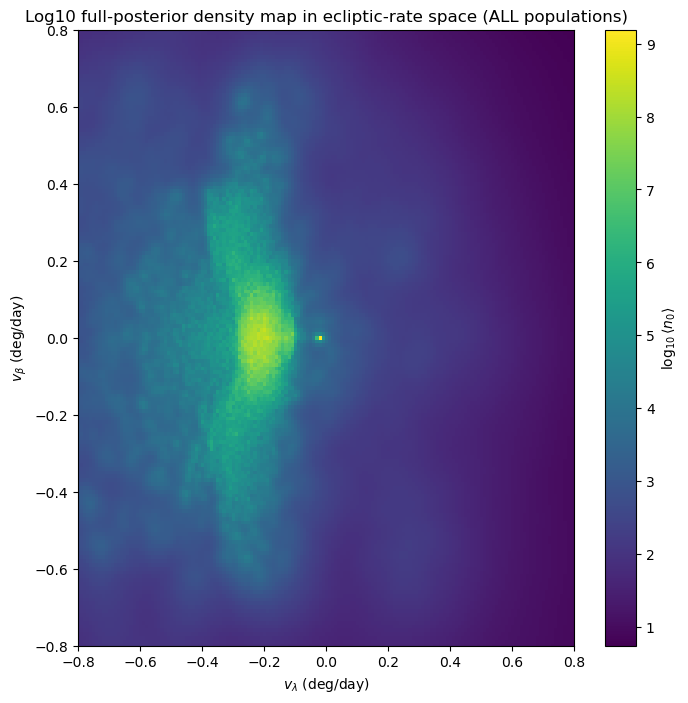

In [29]:
# Plot log10 density map


density_all_map = density_all_flat.reshape(X0.shape)

log_density_all_map = np.log10(density_all_map)

fig, ax = plt.subplots(figsize=(8, 8))

im = ax.pcolormesh(
    X0, Y0, log_density_all_map,
    shading="auto"
)

ax.set_xlim(*xlim)
ax.set_ylim(*ylim)
ax.set_xlabel(r"$v_\lambda$ (deg/day)")
ax.set_ylabel(r"$v_\beta$ (deg/day)")
ax.set_title("Log10 full-posterior density map in ecliptic-rate space (ALL populations)")
fig.colorbar(im, ax=ax, label=r"$\log_{10}\langle n_0 \rangle$")

plt.show()

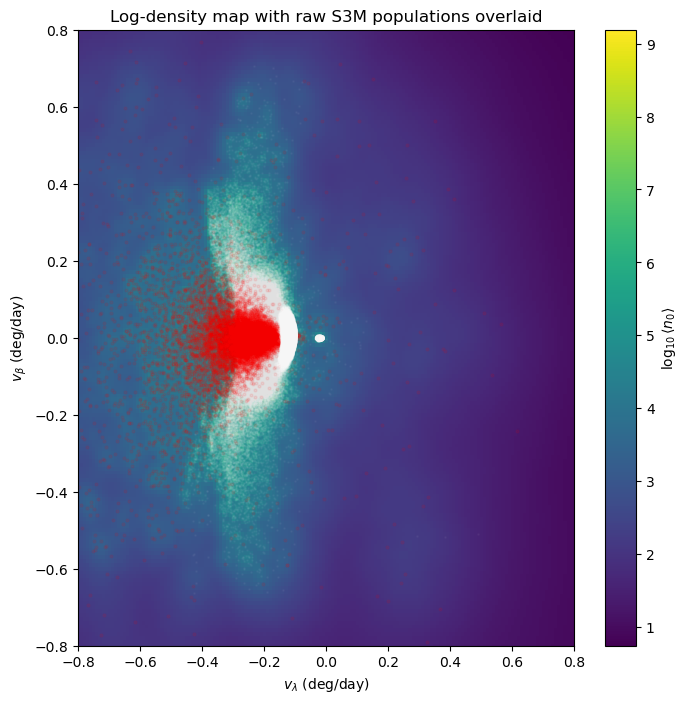

In [30]:
# Overlay raw population points on log-density map

fig, ax = plt.subplots(figsize=(8, 8))

im = ax.pcolormesh(
    X0, Y0, log_density_all_map,
    shading="auto"
)

# Overlay a light scatter of the raw points
ax.scatter(vlam_mba, vbeta_mba, s=1, alpha=0.03, color="white", rasterized=True)
ax.scatter(vlam_neo, vbeta_neo, s=4, alpha=0.08, color="red", rasterized=True)
ax.scatter(vlam_tno, vbeta_tno, s=6, alpha=0.10, color="white", rasterized=True)
ax.scatter(vlam_tjn, vbeta_tjn, s=6, alpha=0.10, color="white", rasterized=True)

ax.set_xlim(*xlim)
ax.set_ylim(*ylim)
ax.set_xlabel(r"$v_\lambda$ (deg/day)")
ax.set_ylabel(r"$v_\beta$ (deg/day)")
ax.set_title("Log-density map with raw S3M populations overlaid")
fig.colorbar(im, ax=ax, label=r"$\log_{10}\langle n_0 \rangle$")

plt.show()

In [31]:
density_neo_flat = evaluate_density_map_full_posterior_2d(
    tree_neo,
    grid_points,
    k=k_map,
    n_d0_grid=n_d0_grid_map,
    show_progress=True,
)

print("Done.")
print("density_neo_flat shape:", density_neo_flat.shape)
print("min density:", np.nanmin(density_neo_flat))
print("max density:", np.nanmax(density_neo_flat))
print("median density:", np.nanmedian(density_neo_flat))

Evaluating density map: 100%|██████████| 25921/25921 [07:58<00:00, 54.15it/s]

Done.
density_neo_flat shape: (25921,)
min density: 5.552269206645225
max density: 1783448.0028101231
median density: 143.8826875057768


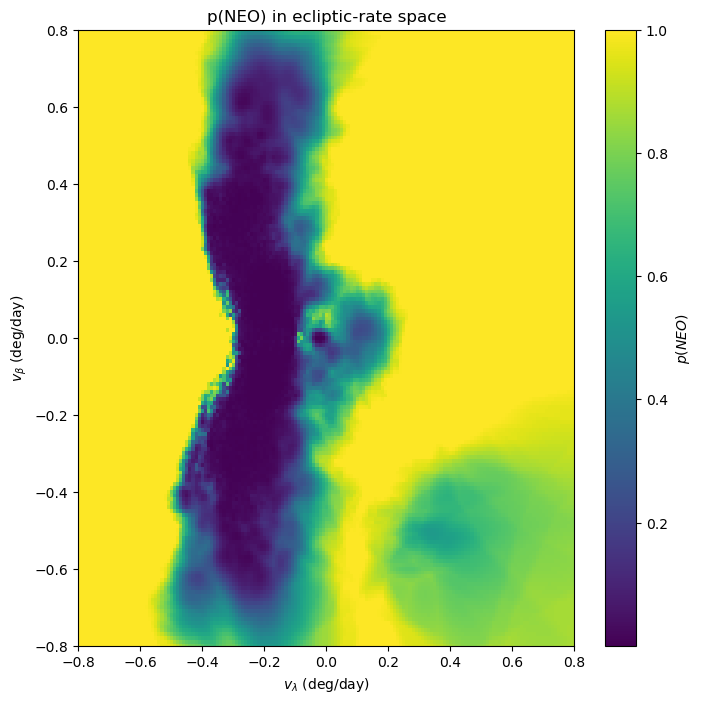

In [32]:
# Plot log10 density map
density_neo_map = density_neo_flat.reshape(X0.shape)

NEOprob = density_neo_map / density_all_map

fig, ax = plt.subplots(figsize=(8, 8))

im = ax.pcolormesh(
    X0, Y0, NEOprob,
    shading="auto"
)

ax.set_xlim(*xlim)
ax.set_ylim(*ylim)
ax.set_xlabel(r"$v_\lambda$ (deg/day)")
ax.set_ylabel(r"$v_\beta$ (deg/day)")
ax.set_title("p(NEO) in ecliptic-rate space")
fig.colorbar(im, ax=ax, label=r"$p(NEO)$")

plt.show()

In [33]:
# Build full-posterior density maps for all 4 populations

k_map = 10
n_d0_grid_map = 400

pop_info = {
    "MBA": {
        "tree": tree_mba,
        "vlam": vlam_mba,
        "vbeta": vbeta_mba,
        "scatter_size": 1,
        "scatter_alpha": 0.05,
    },
    "NEO": {
        "tree": tree_neo,
        "vlam": vlam_neo,
        "vbeta": vbeta_neo,
        "scatter_size": 4,
        "scatter_alpha": 0.08,
    },
    "TNO": {
        "tree": tree_tno,
        "vlam": vlam_tno,
        "vbeta": vbeta_tno,
        "scatter_size": 6,
        "scatter_alpha": 0.10,
    },
    "Trojans": {
        "tree": tree_tjn,
        "vlam": vlam_tjn,
        "vbeta": vbeta_tjn,
        "scatter_size": 6,
        "scatter_alpha": 0.10,
    },
}

density_maps = {}
log_density_maps = {}

for pop_name, info in pop_info.items():
    print(f"\nEvaluating {pop_name} density map...")

    density_flat = evaluate_density_map_full_posterior_2d(
        info["tree"],
        grid_points,
        k=k_map,
        n_d0_grid=n_d0_grid_map,
        show_progress=True,
    )

    density_map = density_flat.reshape(X0.shape)
    log_density_map = np.log10(density_map)

    density_maps[pop_name] = density_map
    log_density_maps[pop_name] = log_density_map

    print(f"{pop_name} done.")
    print("  min density   :", np.nanmin(density_flat))
    print("  max density   :", np.nanmax(density_flat))
    print("  median density:", np.nanmedian(density_flat))


Evaluating MBA density map...


Evaluating density map:   1%|          | 292/25921 [00:05<07:42, 55.38it/s]


KeyboardInterrupt: 

In [ ]:
# Plot all 4 log-density maps

fig, axes = plt.subplots(2, 2, figsize=(14, 12), constrained_layout=True)
axes = axes.ravel()

for ax, pop_name in zip(axes, pop_info.keys()):
    im = ax.pcolormesh(
        X0, Y0, log_density_maps[pop_name],
        shading="auto"
    )

    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_xlabel(r"$v_\lambda$ (deg/day)")
    ax.set_ylabel(r"$v_\beta$ (deg/day)")
    ax.set_title(f"{pop_name}: log10 full-posterior density")

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label(r"$\log_{10}\langle n_0 \rangle$")

plt.show()

In [ ]:
# Plot all 4 log-density maps with raw objects overlaid

fig, axes = plt.subplots(2, 2, figsize=(14, 12), constrained_layout=True)
axes = axes.ravel()

for ax, pop_name in zip(axes, pop_info.keys()):
    info = pop_info[pop_name]

    im = ax.pcolormesh(
        X0, Y0, log_density_maps[pop_name],
        shading="auto"
    )

    ax.scatter(
        info["vlam"],
        info["vbeta"],
        s=info["scatter_size"],
        alpha=info["scatter_alpha"],
        color="white",
        rasterized=True,
    )

    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_xlabel(r"$v_\lambda$ (deg/day)")
    ax.set_ylabel(r"$v_\beta$ (deg/day)")
    ax.set_title(f"{pop_name}: log-density + raw objects")

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label(r"$\log_{10}\langle n_0 \rangle$")

plt.show()

In [ ]:
# Population fraction (Probability) maps from density maps
# p(pop) ~ density_pop / density_all


# Small floor to avoid divide by zero or tiny number blowups
eps = 1e-12


prob_maps = {
    "MBA":      density_maps["MBA"]      / np.maximum(density_all_map, eps),
    "NEO":      density_maps["NEO"]      / np.maximum(density_all_map, eps),
    "TNO":      density_maps["TNO"]      / np.maximum(density_all_map, eps),
    "Trojans":  density_maps["Trojans"]  / np.maximum(density_all_map, eps),
}

fig, axes = plt.subplots(2, 2, figsize=(14, 12), constrained_layout=True)
axes = axes.ravel()

for ax, pop_name in zip(axes, prob_maps.keys()):
    im = ax.pcolormesh(
        X0, Y0, prob_maps[pop_name],
        shading="auto",
        vmin=0.0,
        vmax=1.0,
    )

    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_xlabel(r"$v_\lambda$ (deg/day)")
    ax.set_ylabel(r"$v_\beta$ (deg/day)")
    ax.set_title(f"p({pop_name}) in ecliptic-rate space")

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label(f"p({pop_name})")

plt.show()

In [34]:
# Population dataframes for cloning / per-population workflows
s3m_mba = s3m
s3m_neo = neo
s3m_tno = tno
s3m_tjn = trojan  

In [36]:

# Clone a population by randomizing mean anomaly at obstime

import gc
import numpy as np
from scipy.spatial import cKDTree
import astropy.units as u
from astropy.time import Time
from astropy.coordinates import SkyCoord, GCRS, get_sun

AU_km = 149_597_870.7
mu_sun = 1.32712440018e11  # km^3/s^2

def clone_population_random_mean_anomaly(df, clone_factor, obstime_str, rng=None):
    """
    Clone each orbit clone_factor times by assigning a random mean anomaly
    at obstime_str. Keeps a,e,i,node,argperi fixed and changes only orbital phase
    via t_p.

    Returns repeated orbital element arrays.
    """
    if rng is None:
        rng = np.random.default_rng(0)

    t_obs = Time(obstime_str, scale="tdb")

    a_AU   = df["a"].to_numpy(dtype=np.float32)
    e      = df["e"].to_numpy(dtype=np.float32)
    inc    = df["i"].to_numpy(dtype=np.float32)
    raan   = df["node"].to_numpy(dtype=np.float32)
    argp   = df["argperi"].to_numpy(dtype=np.float32)

    # repeat fixed elements
    a_rep    = np.repeat(a_AU, clone_factor).astype(np.float32)
    e_rep    = np.repeat(e, clone_factor).astype(np.float32)
    inc_rep  = np.repeat(inc, clone_factor).astype(np.float32)
    raan_rep = np.repeat(raan, clone_factor).astype(np.float32)
    argp_rep = np.repeat(argp, clone_factor).astype(np.float32)

    # mean motion in rad/day
    a_km = a_rep.astype(np.float64) * AU_km
    n_rad_s = np.sqrt(mu_sun / (a_km**3))
    n_rad_day = n_rad_s * 86400.0

    # random mean anomaly at observation epoch
    M_rand = rng.uniform(0.0, 2.0*np.pi, size=len(a_rep)).astype(np.float64)

    # choose perihelion time so that M(obstime)=M_rand
    tp_new = (t_obs.mjd - (M_rand / n_rad_day)).astype(np.float32)

    return a_rep, e_rep, inc_rep, raan_rep, argp_rep, tp_new

In [37]:

# Convert orbital elements -> vlam, vbeta using your existing pipeline

def elements_to_vlam_vbeta(
    a_AU, e, inc, raan, argp, tp_mjd,
    obstime_str,
    scorer,
    max_sep_deg=30.0,
    chunk=100_000,
    show_progress=True,
):
    t_obs = Time(obstime_str, scale="tdb")

    # heliocentric ecliptic state
    r_obj_ecl, v_obj_ecl = nsc.elements_to_helio_ecliptic_state(
        a_AU=a_AU,
        e=e,
        inc_deg=inc,
        raan_deg=raan,
        argp_deg=argp,
        tp_mjd=tp_mjd,
        obstime_str=obstime_str,
        method="newton",
        n_iter=10,
        chunk=chunk,
        show_progress=show_progress,
    )

    # ecliptic -> equatorial
    eps = np.deg2rad(23.439291)
    c, s = np.cos(eps), np.sin(eps)

    r_obj_helio = np.column_stack([
        r_obj_ecl[:, 0],
        c * r_obj_ecl[:, 1] - s * r_obj_ecl[:, 2],
        s * r_obj_ecl[:, 1] + c * r_obj_ecl[:, 2],
    ])

    v_obj_helio = np.column_stack([
        v_obj_ecl[:, 0],
        c * v_obj_ecl[:, 1] - s * v_obj_ecl[:, 2],
        s * v_obj_ecl[:, 1] + c * v_obj_ecl[:, 2],
    ])

    # observer state
    _, rE, vE, r_tele = scorer._get_earth_and_observer(obstime_str)

    # topocentric relative vectors
    r_rel = r_obj_helio - (rE + r_tele)
    v_rel = v_obj_helio - vE

    # RA/Dec and RA/Dec rates
    x, y, z = r_rel[:, 0], r_rel[:, 1], r_rel[:, 2]
    vx, vy, vz = v_rel[:, 0], v_rel[:, 1], v_rel[:, 2]

    rho2 = x*x + y*y
    r2   = rho2 + z*z
    rho  = np.sqrt(rho2)

    ra  = np.arctan2(y, x)
    dec = np.arctan2(z, rho)

    dra  = (x*vy - y*vx) / rho2
    ddec = (vz*rho2 - z*(x*vx + y*vy)) / (r2 * rho)

    good = (
        np.isfinite(ra) & np.isfinite(dec) &
        np.isfinite(dra) & np.isfinite(ddec) &
        (rho2 > 0) & np.isfinite(r2) & (r2 > 0)
    )

    ra_deg  = (np.rad2deg(ra[good]) % 360.0)
    dec_deg = np.rad2deg(dec[good])
    dra_deg_day  = np.rad2deg(dra[good])  * 86400.0
    ddec_deg_day = np.rad2deg(ddec[good]) * 86400.0

    # anti-sun cut
    sun_gcrs = get_sun(t_obs).transform_to(GCRS(obstime=t_obs))
    anti = SkyCoord(
        x=-sun_gcrs.cartesian.x,
        y=-sun_gcrs.cartesian.y,
        z=-sun_gcrs.cartesian.z,
        representation_type="cartesian",
        frame=GCRS(obstime=t_obs),
    )

    anti_ra_deg  = anti.spherical.lon.to_value(u.deg) % 360.0
    anti_dec_deg = anti.spherical.lat.to_value(u.deg)

    sc = SkyCoord(ra=ra_deg*u.deg, dec=dec_deg*u.deg, frame=GCRS(obstime=t_obs))
    anti_sc = SkyCoord(ra=anti_ra_deg*u.deg, dec=anti_dec_deg*u.deg, frame=GCRS(obstime=t_obs))
    sep = sc.separation(anti_sc).deg

    m = sep <= max_sep_deg
    ra_deg, dec_deg = ra_deg[m], dec_deg[m]
    dra_deg_day, ddec_deg_day = dra_deg_day[m], ddec_deg_day[m]

    # RA/Dec rates -> ecliptic rates
    vlam, vbeta = nsc.radec_rates_to_ecliptic_rates_at_obstime(
        ra_deg, dec_deg,
        dra_deg_day, ddec_deg_day,
        obstime_str
    )

    finite = np.isfinite(vlam) & np.isfinite(vbeta)
    vlam = vlam[finite].astype(np.float32)
    vbeta = vbeta[finite].astype(np.float32)

    return vlam, vbeta

In [38]:

# Clone configuration (less memory intensive)

clone_sources = {
    "MBA": {
        "df": s3m,
        "scorer": scorer_mba_s3m,
        "clone_factor": 1,   # first test: no MBA cloning yet
        "scatter_size": 1,
        "scatter_alpha": 0.05,
    },
    "NEO": {
        "df": neo,
        "scorer": scorer_neo_s3m,
        "clone_factor": 10,
        "scatter_size": 4,
        "scatter_alpha": 0.08,
    },
    "TNO": {
        "df": tno,
        "scorer": scorer_tno_s3m,
        "clone_factor": 10,
        "scatter_size": 6,
        "scatter_alpha": 0.10,
    },
    "Trojans": {
        "df": trojan,
        "scorer": scorer_tjn_s3m,
        "clone_factor": 10,
        "scatter_size": 6,
        "scatter_alpha": 0.10,
    },
}

rng = np.random.default_rng(42)
overlay_max = 100_000

In [39]:
# Build cloned rate-space populations one at a time
# Keeps only small overlay samples + final maps

clone_overlay = {}
clone_density_maps = {}
clone_density_maps_downweighted = {}

for pop_name, info in clone_sources.items():
    f = info["clone_factor"]
    df = info["df"]

    print(f"\nCloning {pop_name} with factor {f}...")

    a_rep, e_rep, inc_rep, raan_rep, argp_rep, tp_new = clone_population_random_mean_anomaly(
        df, clone_factor=f, obstime_str=obstime_str, rng=rng
    )
    print("  cloned orbit count:", len(a_rep))

    vlam_clone, vbeta_clone = elements_to_vlam_vbeta(
        a_rep, e_rep, inc_rep, raan_rep, argp_rep, tp_new,
        obstime_str=obstime_str,
        scorer=info["scorer"],
        max_sep_deg=max_sep_deg,
        chunk=100_000,
        show_progress=True,
    )
    print(f"  final cloned visible points: {len(vlam_clone)}")

    # raw element arrays no longer needed
    del a_rep, e_rep, inc_rep, raan_rep, argp_rep, tp_new
    gc.collect()

    # keep only a small random subset for plotting overlays
    n_overlay = min(overlay_max, len(vlam_clone))
    idx_overlay = rng.choice(len(vlam_clone), size=n_overlay, replace=False)
    clone_overlay[pop_name] = {
        "vlam": vlam_clone[idx_overlay].copy(),
        "vbeta": vbeta_clone[idx_overlay].copy(),
        "scatter_size": info["scatter_size"],
        "scatter_alpha": info["scatter_alpha"],
    }

    pts_clone = np.column_stack([vlam_clone, vbeta_clone])
    tree_clone = cKDTree(pts_clone)

    density_clone_flat = evaluate_density_map_full_posterior_2d(
        tree_clone,
        grid_points,
        k=k_map,
        n_d0_grid=n_d0_grid_map,
        show_progress=True,
    )

    density_clone_map = density_clone_flat.reshape(X0.shape)
    density_downweighted_map = density_clone_map / f

    clone_density_maps[pop_name] = density_clone_map
    clone_density_maps_downweighted[pop_name] = density_downweighted_map

    print(f"{pop_name} done.")
    print("  raw cloned max density   :", np.nanmax(density_clone_map))
    print("  downweighted max density :", np.nanmax(density_downweighted_map))

    # cleanup large arrays before next population
    del vlam_clone, vbeta_clone, pts_clone, tree_clone, density_clone_flat
    gc.collect()


Cloning MBA with factor 1...
  cloned orbit count: 13883361


Propagate with newton: 100%|██████████| 139/139 [00:11<00:00, 12.31it/s]


  final cloned visible points: 1418638


Evaluating density map: 100%|██████████| 25921/25921 [07:50<00:00, 55.12it/s]


MBA done.
  raw cloned max density   : 393660850.11085695
  downweighted max density : 393660850.11085695

Cloning NEO with factor 10...
  cloned orbit count: 2685110


...

TNO done.
  raw cloned max density   : 4906540402.570972
  downweighted max density : 490654040.25709724

Cloning Trojans with factor 10...
  cloned orbit count: 1798820


Propagate with newton: 100%|██████████| 18/18 [00:01<00:00, 13.80it/s]


  final cloned visible points: 221254


Evaluating density map: 100%|██████████| 25921/25921 [07:49<00:00, 55.23it/s]


Trojans done.
  raw cloned max density   : 397148762.2388458
  downweighted max density : 39714876.22388458


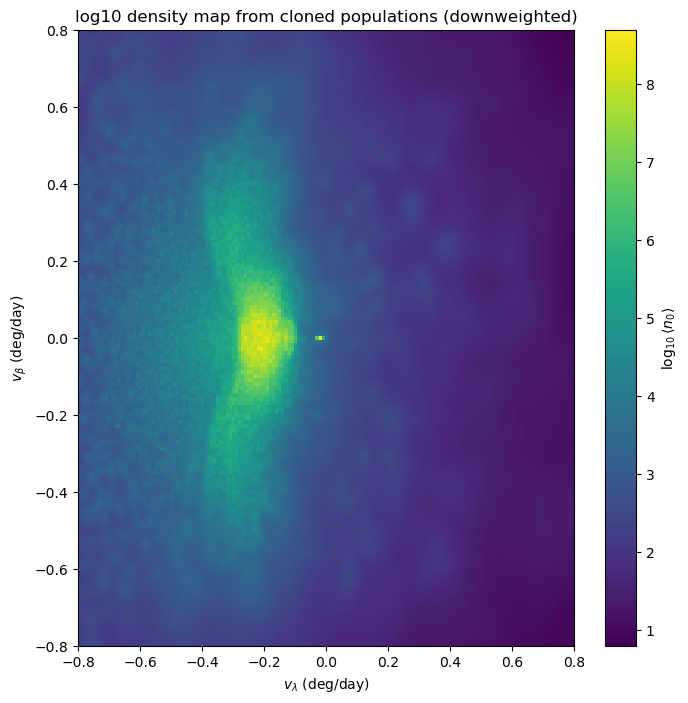

In [40]:

# Combined ALL map from downweighted cloned populations

density_all_clone_downweighted = (
    clone_density_maps_downweighted["MBA"] +
    clone_density_maps_downweighted["NEO"] +
    clone_density_maps_downweighted["TNO"] +
    clone_density_maps_downweighted["Trojans"]
)

log_density_all_clone_downweighted = np.log10(
    np.maximum(density_all_clone_downweighted, 1e-30)
)

fig, ax = plt.subplots(figsize=(8, 8))
im = ax.pcolormesh(X0, Y0, log_density_all_clone_downweighted, shading="auto")

ax.set_xlim(*xlim)
ax.set_ylim(*ylim)
ax.set_xlabel(r"$v_\lambda$ (deg/day)")
ax.set_ylabel(r"$v_\beta$ (deg/day)")
ax.set_title("log10 density map from cloned populations (downweighted)")
fig.colorbar(im, ax=ax, label=r"$\log_{10}\langle n_0 \rangle$")

plt.show()

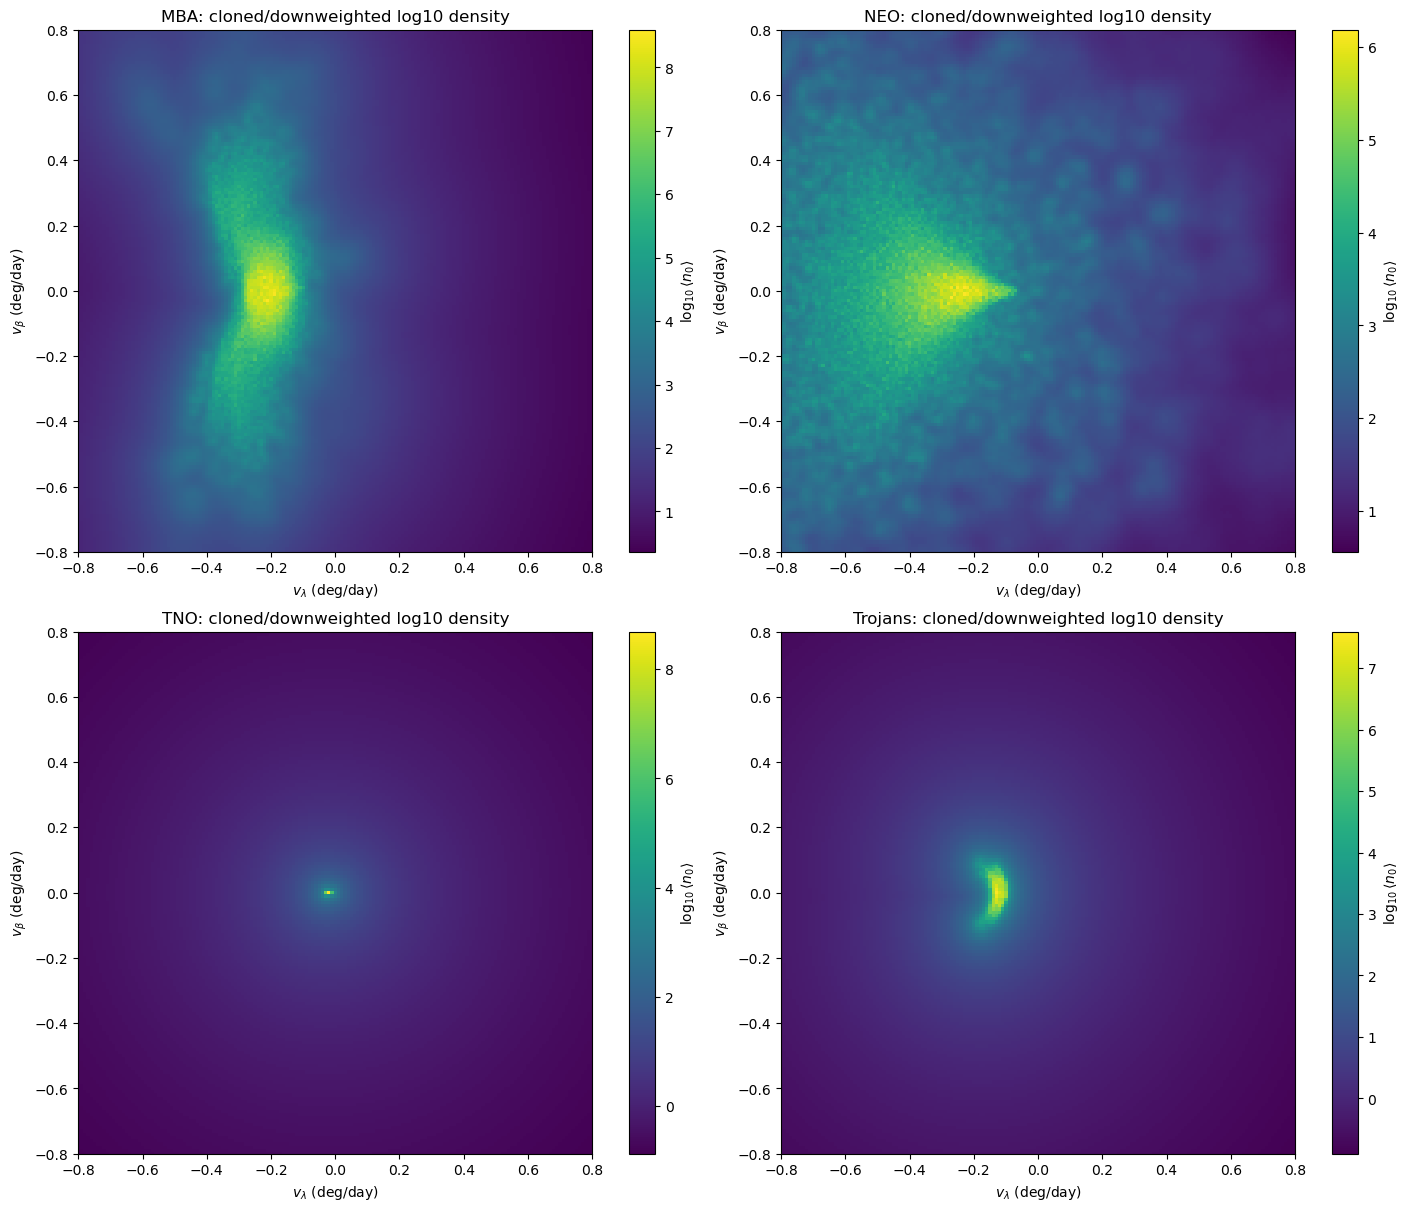

In [41]:

# Plot all 4 cloned/downweighted log-density maps

fig, axes = plt.subplots(2, 2, figsize=(14, 12), constrained_layout=True)
axes = axes.ravel()

for ax, pop_name in zip(axes, clone_density_maps_downweighted.keys()):
    log_map = np.log10(np.maximum(clone_density_maps_downweighted[pop_name], 1e-30))

    im = ax.pcolormesh(
        X0, Y0, log_map,
        shading="auto"
    )

    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_xlabel(r"$v_\lambda$ (deg/day)")
    ax.set_ylabel(r"$v_\beta$ (deg/day)")
    ax.set_title(f"{pop_name}: cloned/downweighted log10 density")

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label(r"$\log_{10}\langle n_0 \rangle$")

plt.show()

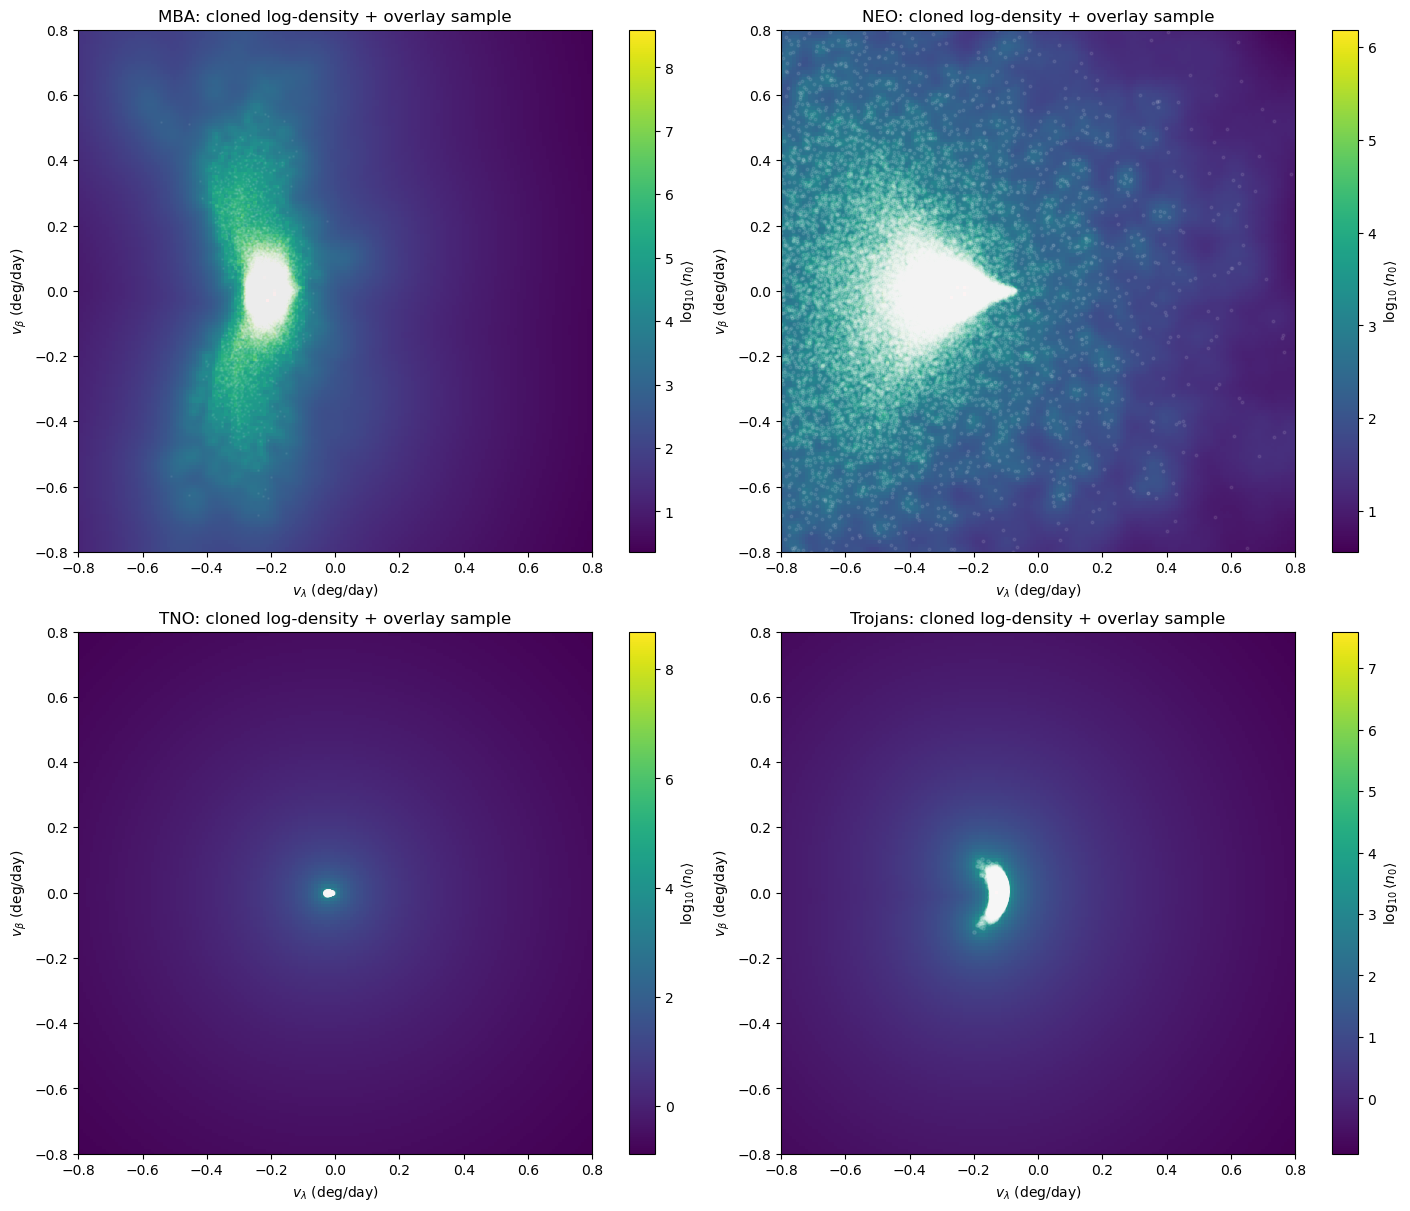

In [42]:

# Plot all 4 cloned/downweighted maps with overlay samples

fig, axes = plt.subplots(2, 2, figsize=(14, 12), constrained_layout=True)
axes = axes.ravel()

for ax, pop_name in zip(axes, clone_density_maps_downweighted.keys()):
    log_map = np.log10(np.maximum(clone_density_maps_downweighted[pop_name], 1e-30))
    overlay = clone_overlay[pop_name]

    im = ax.pcolormesh(
        X0, Y0, log_map,
        shading="auto"
    )

    ax.scatter(
        overlay["vlam"],
        overlay["vbeta"],
        s=overlay["scatter_size"],
        alpha=overlay["scatter_alpha"],
        color="white",
        rasterized=True,
    )

    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_xlabel(r"$v_\lambda$ (deg/day)")
    ax.set_ylabel(r"$v_\beta$ (deg/day)")
    ax.set_title(f"{pop_name}: cloned log-density + overlay sample")

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label(r"$\log_{10}\langle n_0 \rangle$")

plt.show()